In [58]:
# imports
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import re
import scipy.stats as stats
import statsmodels.api as sm

# machine learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.metrics import accuracy_score
from sklearn.linear_model import LogisticRegression
from scipy.stats import pearsonr
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway
from scipy.stats import shapiro, normaltest, zscore
from statsmodels.formula.api import ols
import statsmodels.formula.api as smf
from statsmodels.stats.anova import anova_lm

## Data cleaning and preparing

In [2]:
tsc = pd.read_csv("Tsc2-LE_data_exported_20251015.csv")
tsc.head()

,date,rat_name,rat_ID,DOB,Sex,weight,Genotype,HL_date,invalid,file_name,...,stim_type,analysis_type,complete_block_count,trial_count,hit_percent,FA_percent,UUID,block_size,line,genotype
0,20230117,GP5,161,20220206,Male,483.0,Tsc2_LE_Het,NaN,NaN,32kHz_5-65dB_50ms_4s,...,tone,Tone (Single),30.0,300,0.757143,0.044444,20230117112140_40.0530014187098_3.23855481992454,10,Tsc2,Het
1,20230117,GP6,162,20220206,Male,570.0,Tsc2_LE_WT,NaN,NaN,8kHz_30-90dB_50ms_4s,...,tone,Tone (Single),43.0,433,0.917492,0.223077,20230117112140_180.444997921586_2.7957715020537,10,Tsc2,WT
2,20230117,GP1,144,20220127,Male,558.0,Tsc2_LE_Het,NaN,NaN,4kHz_30-60dB_50ms_4s,...,tone,Tone (Single),45.0,453,0.852201,0.207407,20230117122835_82.660998031497_2.42393043181062,10,Tsc2,Het
3,20230117,GP2,150,20220127,Male,509.0,Tsc2_LE_WT,NaN,NaN,4kHz_30-90dB_50ms_4s,...,tone,Tone (Single),41.0,410,0.853659,0.227642,20230117122835_117.839000746608_2.72426594934181,10,Tsc2,WT
4,20230117,GP3,145,20220127,Male,636.0,Tsc2_LE_Het,NaN,NaN,8kHz_30-90dB_50ms_4s,...,tone,Tone (Single),45.0,459,0.825545,0.108696,20230117133538_98.7920008599758_1.44631039885978,10,Tsc2,Het


In [3]:
fmr1 = pd.read_csv("Fmr1-LE_data_exported_20251015.csv")
fmr1.head(n=15)

,date,rat_name,rat_ID,DOB,Sex,weight,Genotype,HL_date,invalid,file_name,...,stim_type,analysis_type,complete_block_count,trial_count,hit_percent,FA_percent,UUID,block_size,line,genotype
0,20230117,LP3,195,20220613,Male,506,Fmr1-LE_WT,NaN,NaN,16kHz_15-45dB_50ms_4s,...,tone,Tone (Single),37.0,372,0.842912,0.360360,20230117101314_128.279006481171_1.79186604499923,10,Fmr1,WT
1,20230117,LP4,197,20220613,Male,490,Fmr1-LE_KO,NaN,NaN,16kHz_30-90dB_50ms_16s,...,tone,Tone (Single),35.0,351,0.821138,0.152381,20230117101314_143.848998472095_1.45664114318196,10,Fmr1,KO
2,20230117,LP5,196,20220613,Male,502,Fmr1-LE_WT,NaN,NaN,BBN_15-75dB_50-300ms_8s,...,BBN,BBN Mixed Duration,12.0,387,0.845018,0.163793,20230117101317_204.487997666001_2.54813123301631,30,Fmr1,WT
3,20230117,LP6,198,20220613,Male,514,Fmr1-LE_KO,NaN,NaN,8kHz_40-70dB_50ms_8s,...,tone,Tone (Single),39.0,397,0.830935,0.260504,20230117101317_253.467997536063_3.28184222396705,10,Fmr1,KO
4,20230117,Purple1,209,20220613,Male,457,Fmr1-LE_WT,NaN,NaN,32kHz_40-70dB_50ms_4s,...,tone,Tone (Single),49.0,495,0.982709,0.087838,20230117112140_3.45500037074089_2.85635958015692,10,Fmr1,WT
5,20230117,Purple2,210,20220613,Male,503,Fmr1-LE_KO,NaN,NaN,BBN_20-80dB_50-300ms_4s,...,BBN,BBN Mixed Duration,17.0,517,0.839779,0.135484,20230117112140_20.3270070254803_1.96834682257734,30,Fmr1,KO
6,20230117,Purple3,213,20220613,Male,457,Fmr1-LE_KO,NaN,NaN,BBN_20-80dB_100ms_16s,...,BBN,BBN (Standard),42.0,427,0.819398,0.242188,20230117133537_43.9990069717169_1.80065878679998,10,Fmr1,KO
7,20230117,Purple4,211,20220613,Male,506,Fmr1-LE_WT,NaN,NaN,BBN_20-80dB_50-300ms_8s,...,BBN,BBN Mixed Duration,12.0,381,0.883459,0.147826,20230117133537_81.921000033617_3.78937446780336,30,Fmr1,WT
8,20230117,BP1,180,20220206,Male,604,Fmr1-LE_KO,NaN,NaN,32kHz_30-90dB_50ms_4s,...,tone,Tone (Single),40.0,403,0.921986,0.107438,20230117153907_67.1959944069386_3.92357461596229,10,Fmr1,KO
9,20230117,BP2,184,20220206,Male,540,Fmr1-LE_WT,NaN,NaN,4kHz_60-90dB_50ms_12s,...,tone,Tone (Single),38.0,381,0.947368,0.373913,20230117153909_92.334995046258_3.8044259812882,10,Fmr1,WT


In [4]:
double = pd.read_csv("FXS x TSC_data_exported_20251010.csv")
double.head(n=15)

,date,rat_name,rat_ID,DOB,Sex,weight,Genotype,HL_date,invalid,file_name,...,stim_type,analysis_type,complete_block_count,trial_count,hit_percent,FA_percent,UUID,block_size,line,genotype
0,20241017,Orange1,745,20240717,Male,418,Fmr1_KO-Tsc2_WT,NaN,NaN,BBN_60dB_0-0.5s_0catch,...,BBN,Training - BBN,2.0,25,0.960000,NaN,20241017112851_76.5459939837456_0.392612257771637,10,SD,WT
1,20241017,Orange2,746,20240717,Male,360,Fmr1_WT-Tsc2_Het,NaN,NaN,BBN_60dB_0-0.5s_0catch,...,BBN,Training - BBN,2.0,24,0.916667,NaN,20241017112852_111.972999572754_0.275522940750633,10,SD,WT
2,20241017,Orange3,747,20240717,Male,416,Fmr1_WT-Tsc2_WT,NaN,NaN,BBN_60dB_0-0.5s_0catch,...,BBN,Training - BBN,1.0,18,0.833333,NaN,20241017123553_242.635004594922_0.017964664837...,10,SD,WT
3,20241017,Orange4,748,20240717,Male,387,Fmr1_KO-Tsc2_Het,NaN,NaN,BBN_60dB_0-0.5s_0catch,...,BBN,Training - BBN,-inf,2,1.000000,NaN,20241017114036_62.0600033551455_0.310797964739506,10,SD,WT
4,20241018,Orange1,745,20240717,Male,403,Fmr1_KO-Tsc2_WT,NaN,NaN,BBN_60dB_0-0.5s_0catch,...,BBN,Training - BBN,1.0,12,1.000000,NaN,20241018112608_236.40199676156_0.316801995287393,10,SD,WT
5,20241018,Orange2,746,20240717,Male,354,Fmr1_WT-Tsc2_Het,NaN,NaN,BBN_60dB_0-0.5s_0catch,...,BBN,Training - BBN,1.0,18,0.722222,NaN,20241018112609_337.333002313972_0.239525738796159,10,SD,WT
6,20241018,Orange3,747,20240717,Male,414,Fmr1_WT-Tsc2_WT,NaN,NaN,BBN_60dB_0-0.5s_0catch,...,BBN,Training - BBN,9.0,99,0.929293,NaN,20241018123008_86.6400048136711_0.30513311215036,10,SD,WT
7,20241018,Orange4,748,20240717,Male,384,Fmr1_KO-Tsc2_Het,NaN,NaN,BBN_60dB_0-0.5s_0catch,...,BBN,Training - BBN,23.0,231,0.961039,NaN,20241018123009_105.714996904135_0.265311567757095,10,SD,WT
8,20241021,Orange1,745,20240717,Male,414,Fmr1_KO-Tsc2_WT,NaN,NaN,BBN_60dB_0-0.5s_0catch,...,BBN,Training - BBN,5.0,55,0.945455,NaN,20241021111908_450.836007669568_0.390558127304033,10,SD,WT
9,20241021,Orange2,746,20240717,Male,358,Fmr1_WT-Tsc2_Het,NaN,NaN,BBN_60dB_0-0.5s_0catch,...,BBN,Training - BBN,15.0,152,0.907895,NaN,20241021111909_53.0090063810349_0.328105619068787,10,SD,WT


In [5]:
tsc["date"].unique

<bound method Series.unique of 0       20230117
1       20230117
2       20230117
3       20230117
4       20230117
          ...   
8323    20251015
8324    20251015
8325    20251015
8326    20251015
8327    20251015
Name: date, Length: 8328, dtype: int64>

In [6]:
tsc.columns

Index(['date', 'rat_name', 'rat_ID', 'DOB', 'Sex', 'weight', 'Genotype',
       'HL_date', 'invalid', 'file_name', 'experiment', 'phase', 'task',
       'detail', 'stim_type', 'analysis_type', 'complete_block_count',
       'trial_count', 'hit_percent', 'FA_percent', 'UUID', 'block_size',
       'line', 'genotype'],
      dtype='object')

In [7]:
tsc_trials = pd.read_csv("Tsc2-LE_data_exported_trials_20251015.csv")
tsc_trials.head()

,Time_since_file_start_(s),Stim_ID,Trial_type,Attempts_to_complete,Response,Reaction_(s),Type,Stim Source,Freq (kHz),Inten (dB),Dur (ms),Nose Out TL (s),Time Out (s),Delay (s),Trial_number,Block_number,complete_block_number,UUID
0,40.053001,1,1,5,Hit,0.081321,1,tone,32.0,5,50,2,0,3.238555,1,1,1.0,20230117112140_40.0530014187098_3.23855481992454
1,67.011998,8,0,3,CR,2.000002,0,tone,32.0,-100,50,2,4,2.403731,2,1,1.0,20230117112140_40.0530014187098_3.23855481992454
2,74.789999,7,1,2,Hit,0.196028,1,tone,32.0,65,50,2,0,3.582482,3,1,1.0,20230117112140_40.0530014187098_3.23855481992454
3,100.449003,8,0,3,CR,2.000000,0,tone,32.0,-100,50,2,4,2.399536,4,1,1.0,20230117112140_40.0530014187098_3.23855481992454
4,105.440999,4,1,1,Hit,0.242583,1,tone,32.0,35,50,2,0,2.494313,5,1,1.0,20230117112140_40.0530014187098_3.23855481992454


In [8]:
fmr1_trials = pd.read_csv("Fmr1-LE_data_exported_trials_20251015.csv")
fmr1_trials.head(n=15)

,Time_since_file_start_(s),Stim_ID,Trial_type,Attempts_to_complete,Response,Reaction_(s),Type,Stim Source,Freq (kHz),Inten (dB),Dur (ms),Nose Out TL (s),Time Out (s),Delay (s),Trial_number,Block_number,complete_block_number,UUID
0,128.279006,5,1,2,Hit,0.179425,1,tone,16.0,35,50,2,0,1.791866,1,1,1.0,20230117101314_128.279006481171_1.79186604499923
1,137.616001,8,0,2,CR,2.000000,0,tone,16.0,-100,50,2,4,1.199661,2,1,1.0,20230117101314_128.279006481171_1.79186604499923
2,146.185005,1,1,2,Hit,0.035998,1,tone,16.0,15,50,2,0,3.438334,3,1,1.0,20230117101314_128.279006481171_1.79186604499923
3,152.147002,8,0,1,CR,2.000000,0,tone,16.0,-100,50,2,4,1.849163,4,1,1.0,20230117101314_128.279006481171_1.79186604499923
4,158.862999,7,1,2,Hit,0.210240,1,tone,16.0,45,50,2,0,1.911732,5,1,1.0,20230117101314_128.279006481171_1.79186604499923
5,166.267998,4,1,1,Hit,0.333000,1,tone,16.0,30,50,2,0,2.926942,6,1,1.0,20230117101314_128.279006481171_1.79186604499923
6,177.837006,2,1,2,Hit,0.679581,1,tone,16.0,20,50,2,0,3.411680,7,1,1.0,20230117101314_128.279006481171_1.79186604499923
7,185.100002,8,0,1,CR,2.000000,0,tone,16.0,-100,50,2,4,1.785346,8,1,1.0,20230117101314_128.279006481171_1.79186604499923
8,192.195005,3,1,2,Hit,0.237975,1,tone,16.0,25,50,2,0,2.603343,9,1,1.0,20230117101314_128.279006481171_1.79186604499923
9,197.582000,6,1,1,Hit,0.154435,1,tone,16.0,40,50,2,0,3.206334,10,1,1.0,20230117101314_128.279006481171_1.79186604499923


In [9]:
double_trials = pd.read_csv("FXS x TSC_data_exported_trials_20251010.csv")
double_trials.head(n=15)

,Time_since_file_start_(s),Stim_ID,Trial_type,Attempts_to_complete,Response,Reaction_(s),Type,Stim Source,Freq (kHz),Inten (dB),Dur (ms),Nose Out TL (s),Time Out (s),Delay (s),Trial_number,Block_number,complete_block_number,UUID
0,76.545994,1,1,1,Hit,1.806355,1,BBN,0.0,60,300,2,0,0.392612,1,1,1.0,20241017112851_76.5459939837456_0.392612257771637
1,85.074996,1,1,1,Hit,0.060132,1,BBN,0.0,60,300,2,0,0.344607,2,1,1.0,20241017112851_76.5459939837456_0.392612257771637
2,109.837002,1,1,3,Hit,0.717941,1,BBN,0.0,60,300,2,0,0.330606,3,1,1.0,20241017112851_76.5459939837456_0.392612257771637
3,228.694998,1,1,1,Hit,0.301456,1,BBN,0.0,60,300,2,0,0.045595,4,1,1.0,20241017112851_76.5459939837456_0.392612257771637
4,269.197997,1,1,1,Miss,2.000000,1,BBN,0.0,60,300,2,0,0.124481,5,1,1.0,20241017112851_76.5459939837456_0.392612257771637
5,274.588995,1,1,1,Hit,0.236193,1,BBN,0.0,60,300,2,0,0.002659,6,1,1.0,20241017112851_76.5459939837456_0.392612257771637
6,322.886993,1,1,2,Hit,0.007260,1,BBN,0.0,60,300,2,0,0.430737,7,1,1.0,20241017112851_76.5459939837456_0.392612257771637
7,362.492995,1,1,1,Hit,1.285617,1,BBN,0.0,60,300,2,0,0.089251,8,1,1.0,20241017112851_76.5459939837456_0.392612257771637
8,530.647997,1,1,1,Hit,0.042625,1,BBN,0.0,60,300,2,0,0.484505,9,1,1.0,20241017112851_76.5459939837456_0.392612257771637
9,598.660995,1,1,2,Hit,0.128992,1,BBN,0.0,60,300,2,0,0.412999,10,1,1.0,20241017112851_76.5459939837456_0.392612257771637


In [10]:
tsc.shape

(8328, 24)

In [11]:
tsc.isna().sum()

date                       0
rat_name                   0
rat_ID                     0
DOB                        0
Sex                        0
weight                     2
Genotype                   0
HL_date                 8328
invalid                 8328
file_name                  0
experiment                 0
phase                      0
task                       0
detail                  1192
stim_type                  0
analysis_type              0
complete_block_count       0
trial_count                0
hit_percent                0
FA_percent               377
UUID                       0
block_size                 0
line                       0
genotype                   0
dtype: int64

In [12]:
tsc_trials.isna().sum()

Time_since_file_start_(s)        0
Stim_ID                          0
Trial_type                       0
Attempts_to_complete             0
Response                         0
Reaction_(s)                     0
Type                             0
Stim Source                      0
Freq (kHz)                       0
Inten (dB)                       0
Dur (ms)                         0
Nose Out TL (s)                  0
Time Out (s)                     0
Delay (s)                        0
Trial_number                     0
Block_number                     0
complete_block_number        40329
UUID                             0
dtype: int64

In [81]:
fmr1.isna().sum()

date                       0
rat_name                   0
rat_ID                     0
DOB                        0
Sex                        0
weight                     0
Genotype                   0
HL_date                 5634
invalid                 5634
file_name                  0
experiment                 0
phase                      0
task                       0
detail                   477
stim_type                  0
analysis_type              0
complete_block_count       0
trial_count                0
hit_percent                0
FA_percent               217
UUID                       0
block_size                 0
line                       0
genotype                   0
dtype: int64

In [82]:
fmr1_trials.isna().sum()

Time_since_file_start_(s)        0
Stim_ID                          0
Trial_type                       0
Attempts_to_complete             0
Response                         0
Reaction_(s)                     0
Type                             0
Stim Source                      0
Freq (kHz)                       0
Inten (dB)                       0
Dur (ms)                         0
Nose Out TL (s)                  0
Time Out (s)                     0
Delay (s)                        0
Trial_number                     0
Block_number                     0
complete_block_number        29228
UUID                             0
dtype: int64

In [8]:
tsc_trials.isna().sum()

Time_since_file_start_(s)        0
Stim_ID                          0
Trial_type                       0
Attempts_to_complete             0
Response                         0
Reaction_(s)                     0
Type                             0
Stim Source                      0
Freq (kHz)                       0
Inten (dB)                       0
Dur (ms)                         0
Nose Out TL (s)                  0
Time Out (s)                     0
Delay (s)                        0
Trial_number                     0
Block_number                     0
complete_block_number        40329
UUID                             0
dtype: int64

In [13]:
double.isna().sum()

date                       0
rat_name                   0
rat_ID                     0
DOB                        0
Sex                        0
weight                     0
Genotype                   0
HL_date                 2934
invalid                 2934
file_name                  0
experiment                 0
phase                      0
task                       0
detail                  1400
stim_type                  0
analysis_type              0
complete_block_count       0
trial_count                0
hit_percent                0
FA_percent               117
UUID                       0
block_size                 0
line                       0
genotype                   0
dtype: int64

In [14]:
double_trials.isna().sum()

Time_since_file_start_(s)        0
Stim_ID                          0
Trial_type                       0
Attempts_to_complete             0
Response                         0
Reaction_(s)                     0
Type                             0
Stim Source                      0
Freq (kHz)                       0
Inten (dB)                       0
Dur (ms)                         0
Nose Out TL (s)                  0
Time Out (s)                     0
Delay (s)                        0
Trial_number                     0
Block_number                     0
complete_block_number        13970
UUID                             0
dtype: int64

In [9]:
tsc_trials.columns

Index(['Time_since_file_start_(s)', 'Stim_ID', 'Trial_type',
       'Attempts_to_complete', 'Response', 'Reaction_(s)', 'Type',
       'Stim Source', 'Freq (kHz)', 'Inten (dB)', 'Dur (ms)',
       'Nose Out TL (s)', 'Time Out (s)', 'Delay (s)', 'Trial_number',
       'Block_number', 'complete_block_number', 'UUID'],
      dtype='object')

In [10]:
# Check that UUID exists in both
print("UUID in tsc:", 'UUID' in tsc.columns)
print("UUID in tsc_trials:", 'UUID' in tsc_trials.columns)

UUID in tsc: True
UUID in tsc_trials: True


In [11]:
# Check for duplicates
print("Unique UUIDs in tsc:", tsc['UUID'].nunique())
print("Unique UUIDs in tsc_trials:", tsc_trials['UUID'].nunique())

# Optional: check if UUIDs match perfectly between datasets
common = set(tsc['UUID']).intersection(set(tsc_trials['UUID']))
print(f"Common UUIDs: {len(common)}")

Unique UUIDs in tsc: 8328
Unique UUIDs in tsc_trials: 8328
Common UUIDs: 8328


In [83]:
# Check for duplicates
print("Unique UUIDs in tsc:", fmr1['UUID'].nunique())
print("Unique UUIDs in tsc_trials:", fmr1_trials['UUID'].nunique())

# Optional: check if UUIDs match perfectly between datasets
common = set(fmr1['UUID']).intersection(set(fmr1_trials['UUID']))
print(f"Common UUIDs: {len(common)}")

Unique UUIDs in tsc: 5634
Unique UUIDs in tsc_trials: 5634
Common UUIDs: 5634


In [16]:
# Check for duplicates
print("Unique UUIDs in tsc:", double['UUID'].nunique())
print("Unique UUIDs in tsc_trials:", double_trials['UUID'].nunique())

# Optional: check if UUIDs match perfectly between datasets
common = set(double['UUID']).intersection(set(double_trials['UUID']))
print(f"Common UUIDs: {len(common)}")

Unique UUIDs in tsc: 2934
Unique UUIDs in tsc_trials: 2934
Common UUIDs: 2934


In [12]:
tsc["date"].value_counts()

date
20221208    22
20220926    20
20230109    18
20230131    18
20230106    18
            ..
20240611     2
20240617     2
20251013     2
20250318     1
20220514     1
Name: count, Length: 860, dtype: int64

In [13]:
tsc["rat_name"].value_counts()

rat_name
RP1        443
RP2        435
TP5        384
GP2        382
TP6        370
GP1        369
TP4        349
TP2        347
TP1        320
Orange5    291
Orange4    291
Orange6    291
Orange2    288
Orange1    286
RP4        244
RP6        238
RP5        230
RP3        218
Yellow1    216
Orange3    216
Yellow2    215
GP4        181
TP3        179
GP5        178
GP6        178
GP3        164
Blue4      116
Lime4      115
Blue6      115
Blue3      114
Blue5      112
Lime3       80
Lime1       52
Lime2       46
Green1      36
Green2      35
Pink1       34
Pink2       34
Pink3       34
Pink4       34
Green3      34
Green4      34
Name: count, dtype: int64

In [14]:
tsc["rat_ID"].value_counts()

rat_ID
137    443
138    435
163    384
150    382
164    370
144    369
160    349
157    347
156    320
306    291
319    291
311    291
316    288
315    286
140    244
142    238
141    230
139    218
324    216
318    216
327    215
153    181
159    179
161    178
162    178
145    164
381    116
332    115
385    115
370    114
384    112
331     80
328     52
330     46
905     36
906     35
898     34
900     34
901     34
903     34
947     34
948     34
Name: count, dtype: int64

In [15]:
tsc_trials["UUID"].value_counts()

UUID
20240221115324_377.004995942116_3.46455342707717     710
20251009133920_93.5820009559393_0.702689238832728    664
20221213112840_132.857999950647_3.47186139057743     648
20251010133641_154.144003987312_1.45668960412565     640
20251015131856_10.9419945627451_1.57773720924952     630
                                                    ... 
20220620143043_1191.56099818647_3.18274061937669       2
20220816112807_876.653995737433_0.252340906243962      2
20250131131900_1750.2629969269_1.61110887528391        2
20220606155504_2762.88300231099_0.274213096502729      1
20220801143930_6.42500035464764_0.341956279456211      1
Name: count, Length: 8328, dtype: int64

In [16]:
tsc['date'] = pd.to_datetime(tsc['date'], format='%Y%m%d', errors='coerce')
tsc = tsc.dropna(subset=['weight'])

In [84]:
fmr1['date'] = pd.to_datetime(fmr1['date'], format='%Y%m%d', errors='coerce')
fmr1 = fmr1.dropna(subset=['weight'])

In [17]:
double['date'] = pd.to_datetime(double['date'], format='%Y%m%d', errors='coerce')
double = double.dropna(subset=['weight'])

In [17]:
tsc["file_name"].value_counts()

file_name
BBN_20-80dB_50ms_4s               330
16kHz_70dB_8kHz_70dB_300ms_12s    282
BBN_20-80dB_50ms_8s               244
BBN_30-90dB_50ms_4s               225
BBN_20-80dB_300ms_4s              195
                                 ... 
BBN_25-55dB_300ms_12s               1
32kHz_50-80dB_50ms_12s              1
BBN_25-55dB_50ms_4s                 1
BBN_25-55dB_100ms_12s               1
BBN_25-55dB_50ms_12s                1
Name: count, Length: 447, dtype: int64

In [85]:
fmr1["file_name"].value_counts()

file_name
16kHz_70dB_8kHz_70dB_300ms_12s               275
8kHz_70dB_16kHz_70dB_300ms_12s               230
16kHz_70dB_8kHz_70dB_300ms_16s               212
BBN_20-80dB_300ms_4s                         177
BBN_20-80dB_50ms_4s                          170
                                            ... 
8-15.1kHz_70dB_300ms_4s_NG3                    1
8-10.7kHz_70dB_300ms_20s_NG3                   1
16kHz_70dB_8kHz_70dB_300ms_12s_BG_PKN_0dB      1
8-12.7kHz_70dB_300ms_20s_NG3                   1
4kHz_15-45dB_50ms_16s                          1
Name: count, Length: 398, dtype: int64

In [18]:
#def load_data(trials_path, info_path):
    #df_trials = pd.read_csv(trials_path)
    #df_info = pd.read_csv(info_path)
    #return df_trials, df_info

#def uuid_comparer(df1, df2):
    #shared_UUIDs = set(df1['UUID']).intersection(set(df2['UUID']))
    #print(f" Shared UUIDs: {len(shared_UUIDs)}")
    #print(f" UUIDs only in df1: {len(set(df1['UUID']) - shared_UUIDs)}")
    #print(f" UUIDs only in df2: {len(set(df2['UUID']) - shared_UUIDs)}")
    #return shared_UUIDs

#def data_cleaner(df_trials, df_info, shared_UUIDs):
    #"""
    #Filters for shared UUIDs and merges trials with info data.
    #Keeps only relevant/valid rows for analysis.
    #"""
    # Convert shared_UUIDs to list for filtering
    #shared_UUIDs = list(shared_UUIDs)

    # Merge both datasets on UUID
    #merged_df = pd.merge(df_trials, df_info, on="UUID", how="inner")

    # Keep only UUIDs present in both
    #merged_df = merged_df[merged_df['UUID'].isin(shared_UUIDs)]

    # Drop duplicates (if any)
    #merged_df = merged_df.drop_duplicates()
    # Make sure info_df has one row per UUID
    #info_unique = df_info.drop_duplicates(subset=['UUID'])

    # Merge with trials (many-to-one)
    #merged_df = pd.merge(df_trials, info_unique, on="UUID", how="inner")

    #print(f"Merged dataset shape: {merged_df.shape}")

    # Optional: Keep only complete blocks (if that column exists)
    #if 'complete_block_number' in merged_df.columns:
        #merged_df = merged_df[merged_df['complete_block_number'] > 1]

    #print(f" Merged dataset shape: {merged_df.shape}")
    #return merged_df

In [22]:
df_trials = pd.read_csv("Tsc2-LE_data_exported_trials_20251015.csv")
df_info = pd.read_csv("Tsc2-LE_data_exported_20251015.csv")

print("Trials shape:", df_trials.shape)
print("Info shape:", df_info.shape)

def parse_file_name(name):
    name = str(name)
    parts = name.split('_')
    
    result = {
        'StimType': parts[0] if len(parts) > 0 else None,
        'IntensityRange': parts[1] if len(parts) > 1 else None,
        'Duration_ms': None,
        'Delay_s': None
    }

    dur = re.search(r'(\d+)ms', name)
    if dur:
        result['Duration_ms'] = int(dur.group(1))

    delay = re.search(r'(\d+)s', name)
    if delay:
        result['Delay_s'] = int(delay.group(1))

    return pd.Series(result)

parsed_info = df_info['file_name'].apply(parse_file_name)
df_info = pd.concat([df_info, parsed_info], axis=1)

df_info_unique = df_info.drop_duplicates(subset=['UUID'])
print("Unique UUIDs in info:", df_info_unique['UUID'].nunique())

merged_df = pd.merge(df_trials, df_info_unique, on="UUID", how="left")

print("\n Merge Summary:")
print(f"Trials rows: {len(df_trials)}")
print(f"Info unique UUIDs: {len(df_info_unique)}")
print(f"Merged rows: {len(merged_df)}")
print(f"Unique UUIDs in merged_df: {merged_df['UUID'].nunique()}")

print("\nColumns in merged dataset:")
print(merged_df.columns.tolist())

# FILTER TASK TYPES
allowed_tasks = ["Training", "Rxn", "TH", "Baseline"]

merged_df = merged_df[merged_df["task"].isin(allowed_tasks)].copy()

print("\nAfter task filtering:")
print("Remaining tasks:", merged_df["task"].value_counts())
print("Final shape:", merged_df.shape)

display(merged_df.head())

Trials shape: (2952182, 18)
Info shape: (8328, 24)
Unique UUIDs in info: 8328

 Merge Summary:
Trials rows: 2952182
Info unique UUIDs: 8328
Merged rows: 2952182
Unique UUIDs in merged_df: 8328

Columns in merged dataset:
['Time_since_file_start_(s)', 'Stim_ID', 'Trial_type', 'Attempts_to_complete', 'Response', 'Reaction_(s)', 'Type', 'Stim Source', 'Freq (kHz)', 'Inten (dB)', 'Dur (ms)', 'Nose Out TL (s)', 'Time Out (s)', 'Delay (s)', 'Trial_number', 'Block_number', 'complete_block_number', 'UUID', 'date', 'rat_name', 'rat_ID', 'DOB', 'Sex', 'weight', 'Genotype', 'HL_date', 'invalid', 'file_name', 'experiment', 'phase', 'task', 'detail', 'stim_type', 'analysis_type', 'complete_block_count', 'trial_count', 'hit_percent', 'FA_percent', 'block_size', 'line', 'genotype', 'StimType', 'IntensityRange', 'Duration_ms', 'Delay_s']

After task filtering:
Remaining tasks: task
Training    956257
Rxn         826856
TH          619769
Baseline    231273
Name: count, dtype: int64
Final shape: (26341

,Time_since_file_start_(s),Stim_ID,Trial_type,Attempts_to_complete,Response,Reaction_(s),Type,Stim Source,Freq (kHz),Inten (dB),...,trial_count,hit_percent,FA_percent,block_size,line,genotype,StimType,IntensityRange,Duration_ms,Delay_s
0,40.053001,1,1,5,Hit,0.081321,1,tone,32.0,5,...,300,0.757143,0.044444,10,Tsc2,Het,32kHz,5-65dB,50.0,4
1,67.011998,8,0,3,CR,2.000002,0,tone,32.0,-100,...,300,0.757143,0.044444,10,Tsc2,Het,32kHz,5-65dB,50.0,4
2,74.789999,7,1,2,Hit,0.196028,1,tone,32.0,65,...,300,0.757143,0.044444,10,Tsc2,Het,32kHz,5-65dB,50.0,4
3,100.449003,8,0,3,CR,2.000000,0,tone,32.0,-100,...,300,0.757143,0.044444,10,Tsc2,Het,32kHz,5-65dB,50.0,4
4,105.440999,4,1,1,Hit,0.242583,1,tone,32.0,35,...,300,0.757143,0.044444,10,Tsc2,Het,32kHz,5-65dB,50.0,4


In [23]:
merged_df.columns

Index(['Time_since_file_start_(s)', 'Stim_ID', 'Trial_type',
       'Attempts_to_complete', 'Response', 'Reaction_(s)', 'Type',
       'Stim Source', 'Freq (kHz)', 'Inten (dB)', 'Dur (ms)',
       'Nose Out TL (s)', 'Time Out (s)', 'Delay (s)', 'Trial_number',
       'Block_number', 'complete_block_number', 'UUID', 'date', 'rat_name',
       'rat_ID', 'DOB', 'Sex', 'weight', 'Genotype', 'HL_date', 'invalid',
       'file_name', 'experiment', 'phase', 'task', 'detail', 'stim_type',
       'analysis_type', 'complete_block_count', 'trial_count', 'hit_percent',
       'FA_percent', 'block_size', 'line', 'genotype', 'StimType',
       'IntensityRange', 'Duration_ms', 'Delay_s'],
      dtype='object')

In [24]:
merged_df["task"].value_counts()

task
Training    956257
Rxn         826856
TH          619769
Baseline    231273
Name: count, dtype: int64

In [26]:
fmr1['task'].value_counts()

task
Training          2594
Rxn               1318
TH                1008
Holding            397
Discrimination     232
Reset               85
Name: count, dtype: int64

In [25]:
df_trials1 = pd.read_csv("Fmr1-LE_data_exported_trials_20251015.csv")
df_info1 = pd.read_csv("Fmr1-LE_data_exported_20251015.csv")

print("Trials shape:", df_trials1.shape)
print("Info shape:", df_info1.shape)

def parse_file_name(name):
    name = str(name)
    parts = name.split('_')
    
    result = {
        'StimType': parts[0] if len(parts) > 0 else None,
        'IntensityRange': parts[1] if len(parts) > 1 else None,
        'Duration_ms': None,
        'Delay_s': None
    }

    dur = re.search(r'(\d+)ms', name)
    if dur:
        result['Duration_ms'] = int(dur.group(1))

    delay = re.search(r'(\d+)s', name)
    if delay:
        result['Delay_s'] = int(delay.group(1))

    return pd.Series(result)

parsed_info1 = df_info1['file_name'].apply(parse_file_name)
df_info1 = pd.concat([df_info1, parsed_info1], axis=1)

df_info1_unique = df_info1.drop_duplicates(subset=['UUID'])
print("Unique UUIDs in info:", df_info1_unique['UUID'].nunique())

merged_df1 = pd.merge(df_trials1, df_info1_unique, on="UUID", how="left")

print("\n Merge Summary:")
print(f"Trials rows: {len(df_trials1)}")
print(f"Info unique UUIDs: {len(df_info1_unique)}")
print(f"Merged rows: {len(merged_df1)}")
print(f"Unique UUIDs in merged_df: {merged_df1['UUID'].nunique()}")

print("\nColumns in merged dataset:")
print(merged_df1.columns.tolist())

# FILTER TASK TYPES
allowed_tasks = ["Training", "Rxn", "TH", "Baseline"]

merged_df1 = merged_df1[merged_df1["task"].isin(allowed_tasks)].copy()

print("\nAfter task filtering:")
print("Remaining tasks:", merged_df1["task"].value_counts())
print("Final shape:", merged_df1.shape)

display(merged_df1.head())

Trials shape: (2174508, 18)
Info shape: (5634, 24)
Unique UUIDs in info: 5634

 Merge Summary:
Trials rows: 2174508
Info unique UUIDs: 5634
Merged rows: 2174508
Unique UUIDs in merged_df: 5634

Columns in merged dataset:
['Time_since_file_start_(s)', 'Stim_ID', 'Trial_type', 'Attempts_to_complete', 'Response', 'Reaction_(s)', 'Type', 'Stim Source', 'Freq (kHz)', 'Inten (dB)', 'Dur (ms)', 'Nose Out TL (s)', 'Time Out (s)', 'Delay (s)', 'Trial_number', 'Block_number', 'complete_block_number', 'UUID', 'date', 'rat_name', 'rat_ID', 'DOB', 'Sex', 'weight', 'Genotype', 'HL_date', 'invalid', 'file_name', 'experiment', 'phase', 'task', 'detail', 'stim_type', 'analysis_type', 'complete_block_count', 'trial_count', 'hit_percent', 'FA_percent', 'block_size', 'line', 'genotype', 'StimType', 'IntensityRange', 'Duration_ms', 'Delay_s']

After task filtering:
Remaining tasks: task
Training    924871
Rxn         547783
TH          413865
Name: count, dtype: int64
Final shape: (1886519, 45)


,Time_since_file_start_(s),Stim_ID,Trial_type,Attempts_to_complete,Response,Reaction_(s),Type,Stim Source,Freq (kHz),Inten (dB),...,trial_count,hit_percent,FA_percent,block_size,line,genotype,StimType,IntensityRange,Duration_ms,Delay_s
0,128.279006,5,1,2,Hit,0.179425,1,tone,16.0,35,...,372,0.842912,0.36036,10,Fmr1,WT,16kHz,15-45dB,50.0,4
1,137.616001,8,0,2,CR,2.000000,0,tone,16.0,-100,...,372,0.842912,0.36036,10,Fmr1,WT,16kHz,15-45dB,50.0,4
2,146.185005,1,1,2,Hit,0.035998,1,tone,16.0,15,...,372,0.842912,0.36036,10,Fmr1,WT,16kHz,15-45dB,50.0,4
3,152.147002,8,0,1,CR,2.000000,0,tone,16.0,-100,...,372,0.842912,0.36036,10,Fmr1,WT,16kHz,15-45dB,50.0,4
4,158.862999,7,1,2,Hit,0.210240,1,tone,16.0,45,...,372,0.842912,0.36036,10,Fmr1,WT,16kHz,15-45dB,50.0,4


In [29]:
df_trials2 = pd.read_csv("FXS x TSC_data_exported_trials_20251010.csv")
df_info2 = pd.read_csv("FXS x TSC_data_exported_20251010.csv")

print("Trials shape:", df_trials2.shape)
print("Info shape:", df_info2.shape)

def parse_file_name(name):
    name = str(name)
    parts = name.split('_')
    
    result = {
        'StimType': parts[0] if len(parts) > 0 else None,
        'IntensityRange': parts[1] if len(parts) > 1 else None,
        'Duration_ms': None,
        'Delay_s': None
    }

    dur = re.search(r'(\d+)ms', name)
    if dur:
        result['Duration_ms'] = int(dur.group(1))

    delay = re.search(r'(\d+)s', name)
    if delay:
        result['Delay_s'] = int(delay.group(1))

    return pd.Series(result)

parsed_info2 = df_info2['file_name'].apply(parse_file_name)
df_info2 = pd.concat([df_info2, parsed_info2], axis=1)

df_info2_unique = df_info2.drop_duplicates(subset=['UUID'])
print("Unique UUIDs in info:", df_info2_unique['UUID'].nunique())

merged_df2 = pd.merge(df_trials2, df_info2_unique, on="UUID", how="left")

print("\n Merge Summary:")
print(f"Trials rows: {len(df_trials2)}")
print(f"Info unique UUIDs: {len(df_info2_unique)}")
print(f"Merged rows: {len(merged_df2)}")
print(f"Unique UUIDs in merged_df: {merged_df2['UUID'].nunique()}")

print("\nColumns in merged dataset:")
print(merged_df2.columns.tolist())

# FILTER TASK TYPES
allowed_tasks = ["Training", "Rxn", "TH", "Baseline"]

merged_df2 = merged_df2[merged_df2["task"].isin(allowed_tasks)].copy()

print("\nAfter task filtering:")
print("Remaining tasks:", merged_df2["task"].value_counts())
print("Final shape:", merged_df2.shape)

display(merged_df2.head())

Trials shape: (1097312, 18)
Info shape: (2934, 24)
Unique UUIDs in info: 2934

 Merge Summary:
Trials rows: 1097312
Info unique UUIDs: 2934
Merged rows: 1097312
Unique UUIDs in merged_df: 2934

Columns in merged dataset:
['Time_since_file_start_(s)', 'Stim_ID', 'Trial_type', 'Attempts_to_complete', 'Response', 'Reaction_(s)', 'Type', 'Stim Source', 'Freq (kHz)', 'Inten (dB)', 'Dur (ms)', 'Nose Out TL (s)', 'Time Out (s)', 'Delay (s)', 'Trial_number', 'Block_number', 'complete_block_number', 'UUID', 'date', 'rat_name', 'rat_ID', 'DOB', 'Sex', 'weight', 'Genotype', 'HL_date', 'invalid', 'file_name', 'experiment', 'phase', 'task', 'detail', 'stim_type', 'analysis_type', 'complete_block_count', 'trial_count', 'hit_percent', 'FA_percent', 'block_size', 'line', 'genotype', 'StimType', 'IntensityRange', 'Duration_ms', 'Delay_s']

After task filtering:
Remaining tasks: task
Baseline    667046
Training    377226
Name: count, dtype: int64
Final shape: (1044272, 45)


,Time_since_file_start_(s),Stim_ID,Trial_type,Attempts_to_complete,Response,Reaction_(s),Type,Stim Source,Freq (kHz),Inten (dB),...,trial_count,hit_percent,FA_percent,block_size,line,genotype,StimType,IntensityRange,Duration_ms,Delay_s
0,76.545994,1,1,1,Hit,1.806355,1,BBN,0.0,60,...,25,0.96,NaN,10,SD,WT,BBN,60dB,NaN,5
1,85.074996,1,1,1,Hit,0.060132,1,BBN,0.0,60,...,25,0.96,NaN,10,SD,WT,BBN,60dB,NaN,5
2,109.837002,1,1,3,Hit,0.717941,1,BBN,0.0,60,...,25,0.96,NaN,10,SD,WT,BBN,60dB,NaN,5
3,228.694998,1,1,1,Hit,0.301456,1,BBN,0.0,60,...,25,0.96,NaN,10,SD,WT,BBN,60dB,NaN,5
4,269.197997,1,1,1,Miss,2.000000,1,BBN,0.0,60,...,25,0.96,NaN,10,SD,WT,BBN,60dB,NaN,5


**Proportion of one-attempt trials per rat**

Tsc2

In [33]:
# Calculate proportion of one-attempt trials per rat
prop_one_attempt = (
    merged_df.groupby('rat_ID')['Attempts_to_complete']
    .apply(lambda x: (x == 1).sum() / len(x))
    .reset_index(name='prop_one_attempt_trials')
)

# Merge it back into merged_df
merged_df = merged_df.merge(prop_one_attempt, on='rat_ID', how='left')

# Check results
print(merged_df[['rat_ID', 'Attempts_to_complete', 'prop_one_attempt_trials']].head())

   rat_ID  Attempts_to_complete  prop_one_attempt_trials
0     161                     5                 0.805476
1     161                     3                 0.805476
2     161                     2                 0.805476
3     161                     3                 0.805476
4     161                     1                 0.805476


fmr1

In [34]:
# Calculate proportion of one-attempt trials per rat
prop_one_attempt = (
    merged_df1.groupby('rat_ID')['Attempts_to_complete']
    .apply(lambda x: (x == 1).sum() / len(x))
    .reset_index(name='prop_one_attempt_trials')
)

# Merge it back into merged_df1
merged_df1 = merged_df1.merge(prop_one_attempt, on='rat_ID', how='left')

# Check results
print(merged_df1[['rat_ID', 'Attempts_to_complete', 'prop_one_attempt_trials']].head())

   rat_ID  Attempts_to_complete  prop_one_attempt_trials
0     195                     2                 0.805648
1     195                     2                 0.805648
2     195                     2                 0.805648
3     195                     1                 0.805648
4     195                     2                 0.805648


Double Corss

In [35]:
# Calculate proportion of one-attempt trials per rat
prop_one_attempt = (
    merged_df2.groupby('rat_ID')['Attempts_to_complete']
    .apply(lambda x: (x == 1).sum() / len(x))
    .reset_index(name='prop_one_attempt_trials')
)

# Merge it back into merged_df2
merged_df2 = merged_df2.merge(prop_one_attempt, on='rat_ID', how='left')

# Check results
print(merged_df2[['rat_ID', 'Attempts_to_complete', 'prop_one_attempt_trials']].head())

   rat_ID  Attempts_to_complete  prop_one_attempt_trials
0     745                     1                 0.670924
1     745                     1                 0.670924
2     745                     3                 0.670924
3     745                     1                 0.670924
4     745                     1                 0.670924


In [44]:
tsc["Genotype"].value_counts()
fmr1["Genotype"].value_counts()
# double["Genotype"].value_counts()

Genotype
Fmr1-LE_KO    2829
Fmr1-LE_WT    2805
Name: count, dtype: int64

**Genotype color**

In [65]:
genotype_colors = {
    # Pure Tsc2 dataset
    'Tsc2_LE_WT': 'black',     # WT
    'Tsc2_LE_Het': 'blue',     # Tsc mutation

    # Pure Fmr1 dataset
    'Fmr1-LE_WT': 'black',     # WT
    'Fmr1-LE_KO': 'red',       # Fmr1 mutation

    # Double-cross combinations
    'Fmr1_KO-Tsc2_WT': 'red',      # Fmr1 mutant only
    'Fmr1_WT-Tsc2_Het': 'blue',    # Tsc mutant only
    'Fmr1_WT-Tsc2_WT': 'black',    # both WT
    'Fmr1_KO-Tsc2_Het': 'purple'   # double-cross mutant
}

In [66]:
active_palette = {
    g: genotype_colors[g] 
    for g in merged_df['Genotype'].unique() 
    if g in genotype_colors
}

## Gender Difference & TSC, Fmr1, Double Cross Genotypes

**Gender & Genotypes & First-attempt completion rate (Use the mean value for each rats)**

**Tsc2_LE_WT & Tsc2_LE_Het**

In [39]:
# Aggregate by rat_ID
rat_summary = merged_df.groupby(['rat_ID', 'Sex', 'Genotype', 'task'])['prop_one_attempt_trials'].mean().reset_index()
print(rat_summary.head(15))

    rat_ID   Sex     Genotype      task  prop_one_attempt_trials
0      137  Male   Tsc2_LE_WT       Rxn                 0.729221
1      137  Male   Tsc2_LE_WT        TH                 0.729221
2      137  Male   Tsc2_LE_WT  Training                 0.729221
3      138  Male  Tsc2_LE_Het       Rxn                 0.740674
4      138  Male  Tsc2_LE_Het        TH                 0.740674
5      138  Male  Tsc2_LE_Het  Training                 0.740674
6      139  Male  Tsc2_LE_Het       Rxn                 0.658197
7      139  Male  Tsc2_LE_Het        TH                 0.658197
8      139  Male  Tsc2_LE_Het  Training                 0.658197
9      140  Male   Tsc2_LE_WT       Rxn                 0.780365
10     140  Male   Tsc2_LE_WT        TH                 0.780365
11     140  Male   Tsc2_LE_WT  Training                 0.780365
12     141  Male  Tsc2_LE_Het       Rxn                 0.782662
13     141  Male  Tsc2_LE_Het        TH                 0.782662
14     141  Male  Tsc2_LE

In [40]:
rat_summary['Sex'].value_counts()

Sex
Male      64
Female    46
Name: count, dtype: int64

**Side-by-side panels by Task  type, box grouped by Genotype and colored by Sex.**

<Figure size 1600x1000 with 0 Axes>

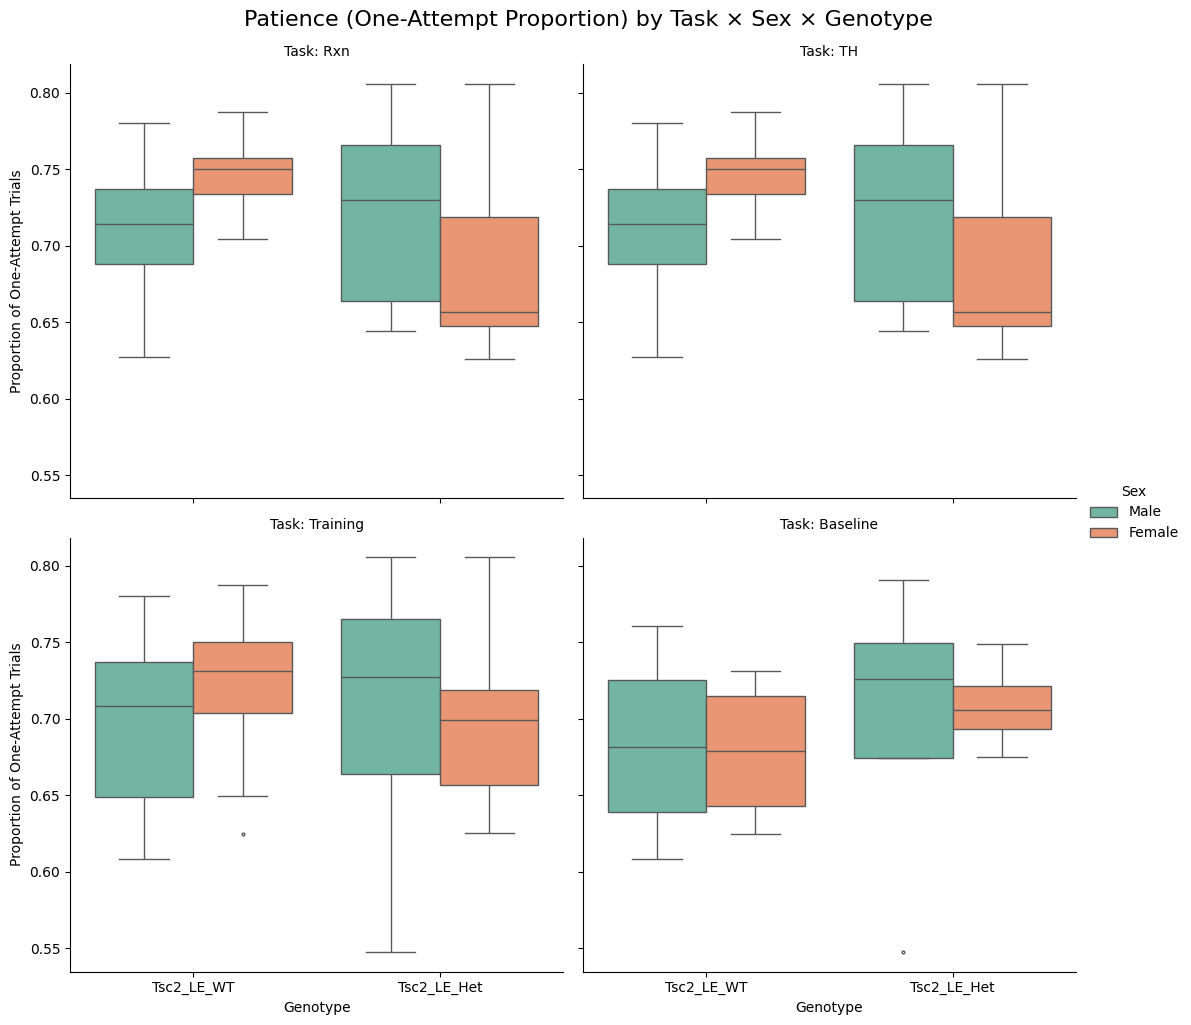

In [42]:
plt.figure(figsize=(16, 10))

g = sns.catplot(
    data=rat_summary,
    x='Genotype',
    y='prop_one_attempt_trials',
    hue='Sex',
    col='task',
    kind='box',
    col_wrap=2,
    height=5,
    aspect=1.1,
    palette='Set2',
    fliersize=2
)

g.set_titles("Task: {col_name}")
g.set_axis_labels("Genotype", "Proportion of One-Attempt Trials")
g.fig.suptitle("Patience (One-Attempt Proportion) by Task × Sex × Genotype", y=1.02, fontsize=16)

plt.show()

In [47]:
rat_summary1 = merged_df1.groupby(['rat_ID', 'Genotype', 'task'])['prop_one_attempt_trials'].mean().reset_index()
print(rat_summary1.head(15))

    rat_ID    Genotype      task  prop_one_attempt_trials
0      180  Fmr1-LE_KO       Rxn                 0.706736
1      180  Fmr1-LE_KO        TH                 0.706736
2      180  Fmr1-LE_KO  Training                 0.706736
3      181  Fmr1-LE_KO       Rxn                 0.637851
4      181  Fmr1-LE_KO        TH                 0.637851
5      181  Fmr1-LE_KO  Training                 0.637851
6      182  Fmr1-LE_KO       Rxn                 0.627854
7      182  Fmr1-LE_KO        TH                 0.627854
8      182  Fmr1-LE_KO  Training                 0.627854
9      183  Fmr1-LE_KO       Rxn                 0.638871
10     183  Fmr1-LE_KO        TH                 0.638871
11     183  Fmr1-LE_KO  Training                 0.638871
12     184  Fmr1-LE_WT       Rxn                 0.616125
13     184  Fmr1-LE_WT        TH                 0.616125
14     184  Fmr1-LE_WT  Training                 0.616125


In [50]:
rat_summary2 = merged_df2.groupby(['rat_ID', 'Genotype', 'task'])['prop_one_attempt_trials'].mean().reset_index()
print(rat_summary2.head(15))

    rat_ID          Genotype      task  prop_one_attempt_trials
0      744   Fmr1_KO-Tsc2_WT  Baseline                 0.828806
1      744   Fmr1_KO-Tsc2_WT  Training                 0.828806
2      745   Fmr1_KO-Tsc2_WT  Training                 0.670924
3      746  Fmr1_WT-Tsc2_Het  Baseline                 0.782163
4      746  Fmr1_WT-Tsc2_Het  Training                 0.782163
5      747   Fmr1_WT-Tsc2_WT  Baseline                 0.757063
6      747   Fmr1_WT-Tsc2_WT  Training                 0.757063
7      748  Fmr1_KO-Tsc2_Het  Baseline                 0.703859
8      748  Fmr1_KO-Tsc2_Het  Training                 0.703859
9      749   Fmr1_WT-Tsc2_WT  Baseline                 0.824581
10     749   Fmr1_WT-Tsc2_WT  Training                 0.824581
11     769  Fmr1_WT-Tsc2_Het  Baseline                 0.725540
12     769  Fmr1_WT-Tsc2_Het  Training                 0.725540
13     770   Fmr1_KO-Tsc2_WT  Baseline                 0.788403
14     770   Fmr1_KO-Tsc2_WT  Training  

In [ ]:
plt.figure(figsize=(16, 10))

g = sns.catplot(
    data=rat_summary,
    x='Genotype',
    y='prop_one_attempt_trials',
    hue='Sex',
    col='task',
    kind='box',
    col_wrap=2,
    height=5,
    aspect=1.1,
    palette='Set2',
    fliersize=2
)

g.set_titles("Task: {col_name}")
g.set_axis_labels("Genotype", "Proportion of One-Attempt Trials")
g.fig.suptitle("Patience (One-Attempt Proportion) by Task × Sex × Genotype", y=1.02, fontsize=16)

plt.show()

**Check for Normality so that we can determine which statistical tests can be used for analysis**

**Normality of the raw dependent variable**

Shapiro-Wilk p-value: 0.0041


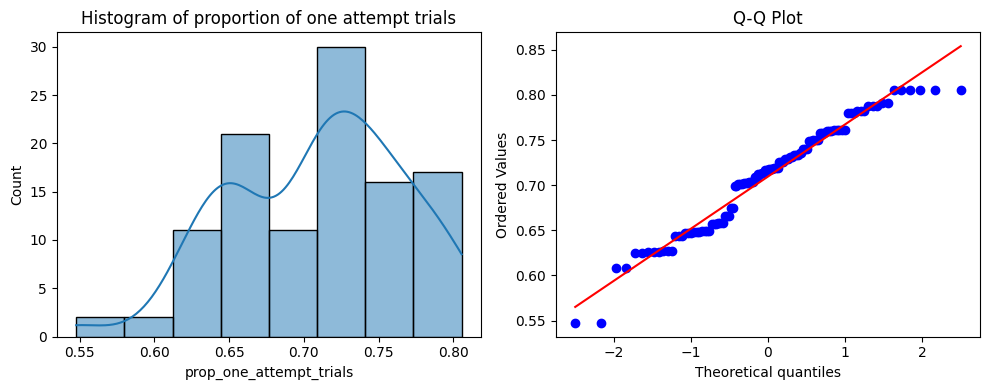

In [53]:
# Shapiro-Wilk test
stat, p = shapiro(rat_summary['prop_one_attempt_trials'])
print(f"Shapiro-Wilk p-value: {p:.4f}")

# Histogram and Q-Q plot
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
sns.histplot(rat_summary['prop_one_attempt_trials'], kde=True)
plt.title('Histogram of proportion of one attempt trials')

plt.subplot(1, 2, 2)
stats.probplot(rat_summary['prop_one_attempt_trials'], dist="norm", plot=plt)
plt.title('Q-Q Plot')

plt.tight_layout()
plt.show()

**ANOVA requires normality of residuals**

                              sum_sq    df         F    PR(>F)
C(Sex)                      0.000113   1.0  0.031531  0.859443
C(Genotype)                 0.000291   1.0  0.080923  0.776677
C(task)                     0.007891   3.0  0.732424  0.535213
C(Sex):C(Genotype)          0.011259   1.0  3.135161  0.079863
C(Sex):C(task)              0.000048   3.0  0.004411  0.999594
C(Genotype):C(task)         0.005335   3.0  0.495188  0.686491
C(Sex):C(Genotype):C(task)  0.005776   3.0  0.536118  0.658668
Residual                    0.337573  94.0       NaN       NaN
Residual Shapiro-Wilk p-value: 0.1556


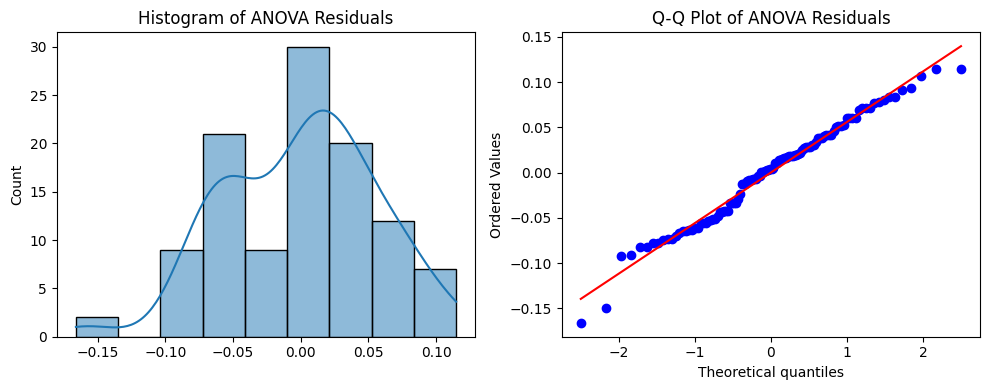

In [ ]:
# Fit ANOVA model
model = ols('prop_one_attempt_trials ~ C(Sex) * C(Genotype) * C(task)', 
            data=rat_summary).fit()

anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

# Extract residuals
residuals = model.resid

# Shapiro-Wilk on residuals
stat, p = shapiro(residuals)
print(f"Residual Shapiro-Wilk p-value: {p:.4f}")

# Plots
plt.figure(figsize=(10, 4))

# Histogram
plt.subplot(1, 2, 1)
sns.histplot(residuals, kde=True)
plt.title("Histogram of ANOVA Residuals")

# Q-Q plot
plt.subplot(1, 2, 2)
stats.probplot(residuals, dist="norm", plot=plt)
plt.title("Q-Q Plot of ANOVA Residuals")

plt.tight_layout()
plt.show()

A three-way ANOVA showed that sex, genotype, task type, and their interactions do not significantly predict variation in the proportion of one-attempt trials among Tsc2 rats. Although the Sex × Genotype interaction approached significance (p = 0.08), it did not reach the conventional alpha threshold. All other factors had p-values far above 0.05. A Shapiro–Wilk test of the model residuals (p = 0.156) confirmed that the normality assumption was met. These findings suggest that one-attempt efficiency is relatively stable across biological and task-related factors within this dataset.

**Furthur Visualizations**

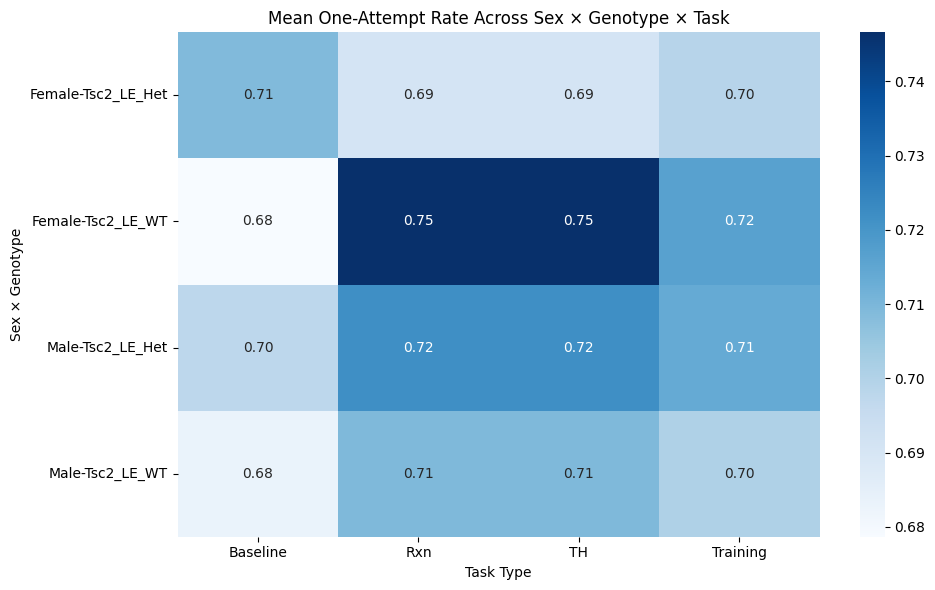

In [59]:
heat = rat_summary.groupby(['Sex','Genotype','task'])['prop_one_attempt_trials'].mean().unstack()

plt.figure(figsize=(10,6))
sns.heatmap(heat, annot=True, cmap='Blues', fmt=".2f")
plt.title("Mean One-Attempt Rate Across Sex × Genotype × Task")
plt.ylabel("Sex × Genotype")
plt.xlabel("Task Type")
plt.tight_layout()
plt.show()

c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\seaborn\axisgrid.py:854: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  func(*plot_args, **plot_kwargs)


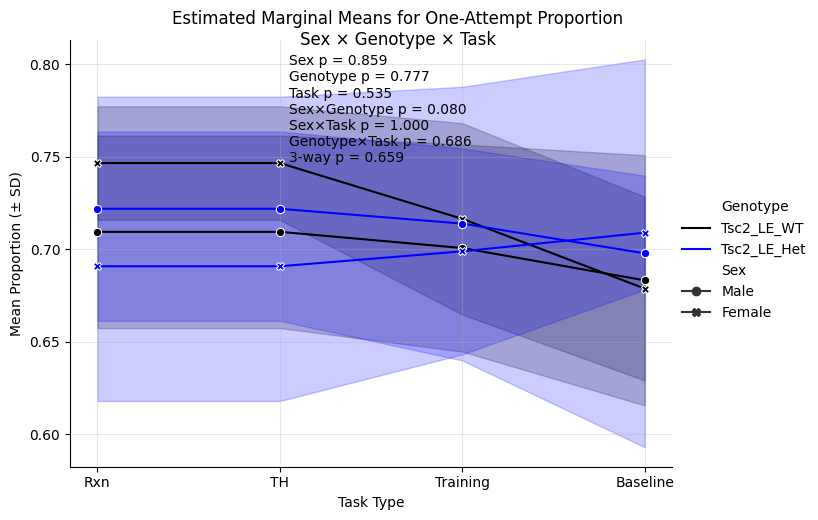

In [70]:
import seaborn as sns
import matplotlib.pyplot as plt

# Build palette for only the genotypes that appear in the TSC dataset
active_palette = {g: genotype_colors[g] for g in rat_summary['Genotype'].unique()}

g = sns.relplot(
    data=rat_summary,
    x='task',
    y='prop_one_attempt_trials',
    hue='Genotype',
    palette=active_palette,      # APPLY COLOR RULES HERE
    style='Sex',
    kind='line',
    markers=True,
    dashes=False,
    ci='sd',
    height=5,
    aspect=1.4
)

g.fig.suptitle("Estimated Marginal Means for One-Attempt Proportion\nSex × Genotype × Task", y=1.03)
plt.xlabel("Task Type")
plt.ylabel("Mean Proportion (± SD)")
plt.grid(alpha=0.3)

# Add ANOVA table text box
pvals = anova_table['PR(>F)']
text = (
    f"Sex p = {pvals['C(Sex)']:.3f}\n"
    f"Genotype p = {pvals['C(Genotype)']:.3f}\n"
    f"Task p = {pvals['C(task)']:.3f}\n"
    f"Sex×Genotype p = {pvals['C(Sex):C(Genotype)']:.3f}\n"
    f"Sex×Task p = {pvals['C(Sex):C(task)']:.3f}\n"
    f"Genotype×Task p = {pvals['C(Genotype):C(task)']:.3f}\n"
    f"3-way p = {pvals['C(Sex):C(Genotype):C(task)']:.3f}"
)

plt.text(1.05, rat_summary['prop_one_attempt_trials'].max(),
         text, fontsize=10, va='top')

plt.show()

**Hypothesis: Autism model rats will have a lower # of single-attempt trials for longer delay times (>2.5 seconds) than wild type rats**


In [72]:
def get_long_delay_summary(df):
    # Filter long-delay trials
    long_df = df[df['Delay (s)'] > 2.5]

    # Compute per-rat proportion of single-attempt trials
    rat_df = (
        long_df
        .groupby(['rat_ID', 'Genotype', 'Sex'])['Attempts_to_complete']
        .apply(lambda x: (x == 1).mean())
        .reset_index(name='prop_one_attempt_longDelay')
    )
    return rat_df

In [73]:
tsc_long = get_long_delay_summary(merged_df)
fmr1_long = get_long_delay_summary(merged_df1)
double_long = get_long_delay_summary(merged_df2)

In [74]:
def check_normality(rat_df, label):
    print(f"\n---- Normality Check for {label} ----")
    stat, p = stats.shapiro(rat_df['prop_one_attempt_longDelay'])
    print(f"Shapiro-Wilk p = {p:.4f}")

    plt.figure(figsize=(10,4))

    plt.subplot(1,2,1)
    sns.histplot(rat_df['prop_one_attempt_longDelay'], kde=True)
    plt.title(f'{label} Histogram')

    plt.subplot(1,2,2)
    stats.probplot(rat_df['prop_one_attempt_longDelay'], dist="norm", plot=plt)
    plt.title(f'{label} Q-Q Plot')

    plt.tight_layout()
    plt.show()


---- Normality Check for TSC ----
Shapiro-Wilk p = 0.7290


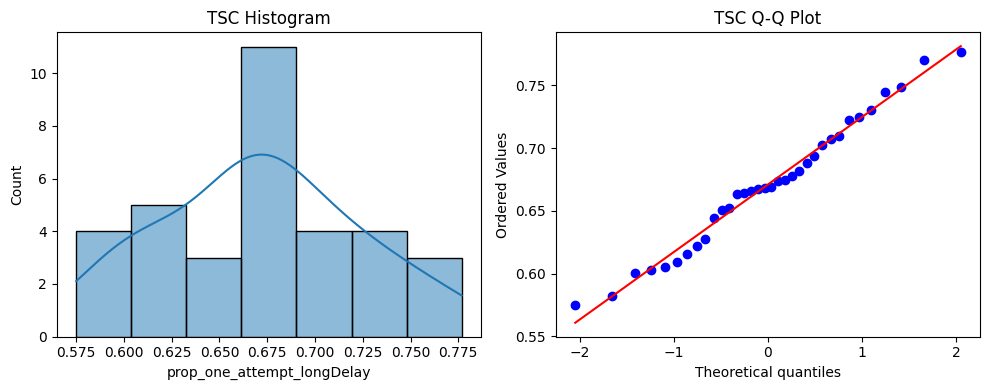


---- Normality Check for FMR1 ----
Shapiro-Wilk p = 0.6818


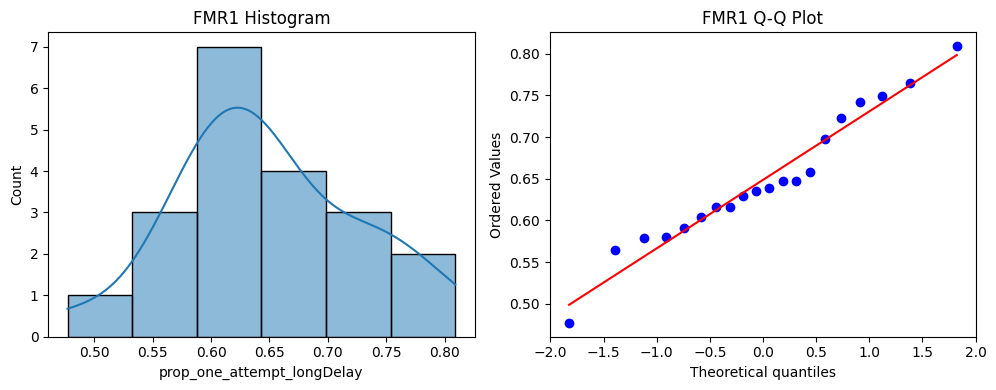


---- Normality Check for Double Cross ----
Shapiro-Wilk p = 0.2382


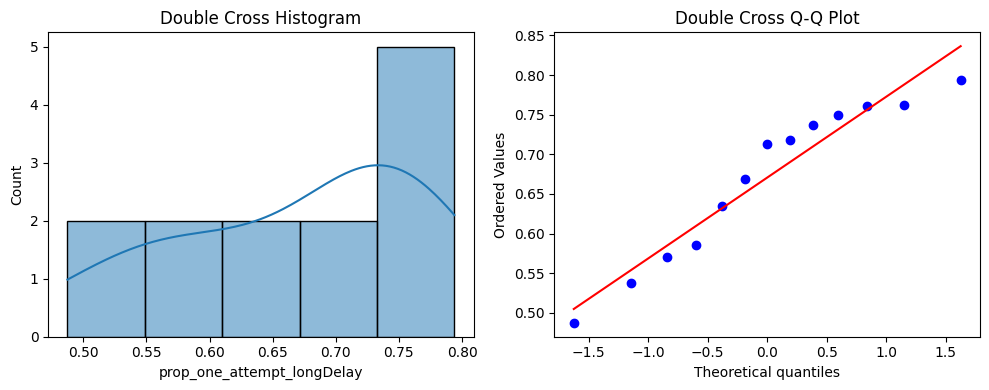

In [75]:
check_normality(tsc_long, "TSC")
check_normality(fmr1_long, "FMR1")
check_normality(double_long, "Double Cross")

Since all of the Shapiro-Wilk p-values are larger than 0.05, we can use the independent t-test in this case.

In [76]:
def compare_mutant_vs_wt(rat_df, label):
    print(f"\n===== {label} Comparison =====")

    # Identify WT and mutant
    if label == "TSC":
        wt = rat_df[rat_df['Genotype'] == 'Tsc2_LE_WT']
        mut = rat_df[rat_df['Genotype'] == 'Tsc2_LE_Het']
    elif label == "FMR1":
        wt = rat_df[rat_df['Genotype'] == 'Fmr1-LE_WT']
        mut = rat_df[rat_df['Genotype'] == 'Fmr1-LE_KO']
    else:  # double cross
        wt = rat_df[rat_df['Genotype'] == 'Fmr1_WT-Tsc2_WT']
        mut = rat_df[rat_df['Genotype'] == 'Fmr1_KO-Tsc2_Het']  # double mutant

    # Normality check
    p = stats.shapiro(rat_df['prop_one_attempt_longDelay'])[1]
    
    if p > 0.05:
        print("Using independent t-test")
        test = stats.ttest_ind(mut['prop_one_attempt_longDelay'],
                               wt['prop_one_attempt_longDelay'],
                               equal_var=False)
    else:
        print("Using Mann-Whitney U test")
        test = stats.mannwhitneyu(mut['prop_one_attempt_longDelay'],
                                  wt['prop_one_attempt_longDelay'],
                                  alternative='less')  # hypothesis: mutant < WT
    
    print(test)

In [77]:
compare_mutant_vs_wt(tsc_long, "TSC")
compare_mutant_vs_wt(fmr1_long, "FMR1")
compare_mutant_vs_wt(double_long, "Double Cross")


===== TSC Comparison =====
Using independent t-test
TtestResult(statistic=np.float64(-0.4981868419110907), pvalue=np.float64(0.6220165710390941), df=np.float64(29.74099091262233))

===== FMR1 Comparison =====
Using independent t-test
TtestResult(statistic=np.float64(-0.09902529937446145), pvalue=np.float64(0.9222446481148726), df=np.float64(17.484873998266686))

===== Double Cross Comparison =====
Using independent t-test
TtestResult(statistic=np.float64(-4.668576757194563), pvalue=np.float64(0.024819593864348316), df=np.float64(2.623847123558541))


In [83]:
genotype_colors = {
    # TSC
    'Tsc2_LE_WT': 'black',
    'Tsc2_LE_Het': 'blue',

    # FMR1
    'Fmr1-LE_WT': 'black',
    'Fmr1-LE_KO': 'red',

    # Double-cross
    'Fmr1_KO-Tsc2_WT': 'red',
    'Fmr1_WT-Tsc2_Het': 'blue',
    'Fmr1_WT-Tsc2_WT': 'black',
    'Fmr1_KO-Tsc2_Het': 'purple'
}
def get_active_palette(df):
    return {g: genotype_colors[g] for g in df['Genotype'].unique() if g in genotype_colors}

In [84]:
def plot_long_delay_by_sex(rat_df, label):
    # Build genotype-based palette
    active_palette = get_active_palette(rat_df)

    g = sns.catplot(
        data=rat_df,
        x='Genotype',
        y='prop_one_attempt_longDelay',
        hue='Genotype',              # hue now matches palette keys
        col='Sex',                   # separate panels for Male/Female
        kind='box',
        palette=active_palette,
        height=5,
        aspect=0.9,
        fliersize=2
    )

    g.set_titles(col_template="{col_name}")
    g.set_axis_labels("Genotype", "Proportion of One-Attempt Trials (Delay > 2.5s)")
    g.fig.suptitle(f"Long-Delay One-Attempt Proportion — {label}", y=1.03)
    plt.show()

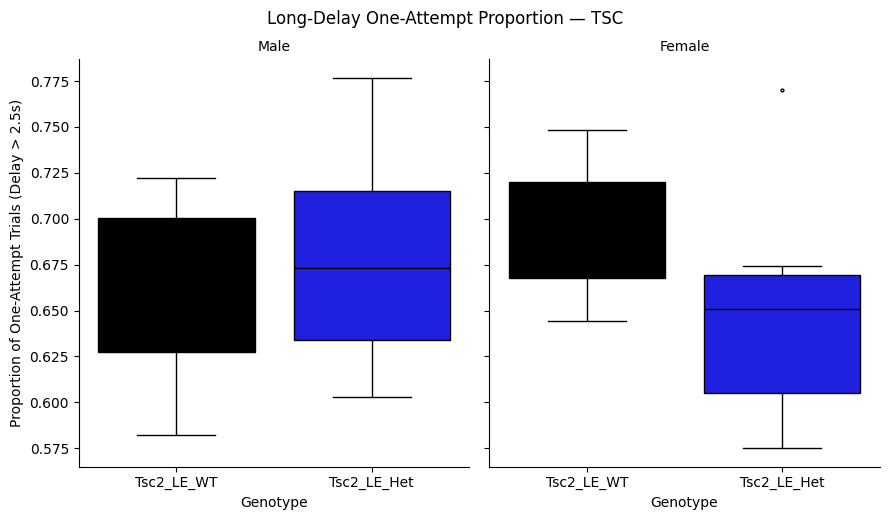

In [89]:
plot_long_delay_by_sex(tsc_long, "TSC")

In [87]:
def plot_long_delay_genotype_only(rat_df, label):
    active_palette = get_active_palette(rat_df)

    plt.figure(figsize=(7,5))
    sns.boxplot(
        data=rat_df,
        x='Genotype',
        y='prop_one_attempt_longDelay',
        palette=active_palette
    )
    sns.stripplot(
        data=rat_df,
        x='Genotype',
        y='prop_one_attempt_longDelay',
        color='black',
        alpha=0.5,
        jitter=True
    )
    plt.title(f"{label}: Long-Delay One-Attempt Proportion")
    plt.ylabel("Proportion of One-Attempt Trials (Delay > 2.5s)")
    plt.xlabel("Genotype")
    plt.tight_layout()
    plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_37088\2646142434.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


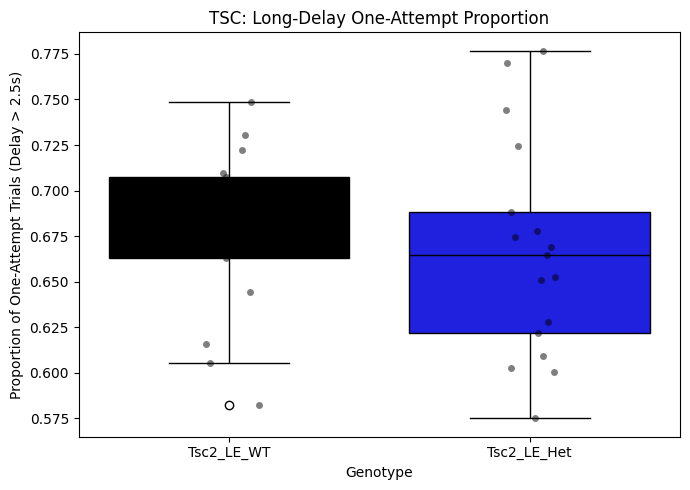

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_37088\2646142434.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


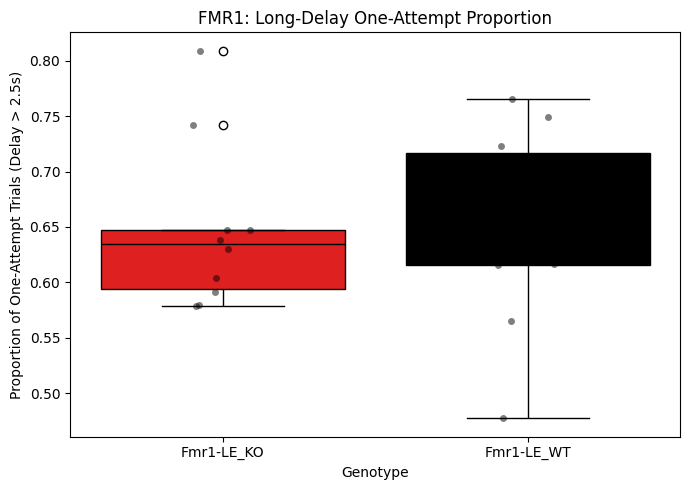

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_37088\2646142434.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


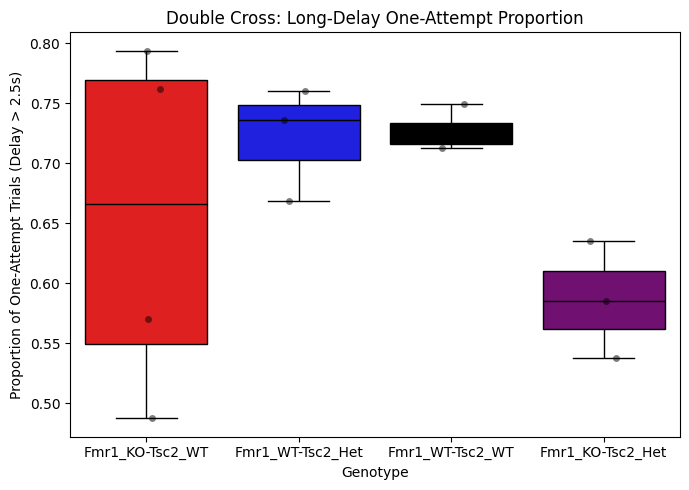

In [88]:
plot_long_delay_genotype_only(tsc_long, "TSC")
plot_long_delay_genotype_only(fmr1_long, "FMR1")
plot_long_delay_genotype_only(double_long, "Double Cross")

Across the three genetic models, only the double-cross mutant rats exhibited significantly reduced patience during long-delay trials. Neither Tsc2 heterozygous rats nor Fmr1 knockout rats showed deficits in their proportion of single-attempt completions. In contrast, the Fmr1_KO–Tsc2_Het double mutants demonstrated a robust reduction in single-attempt long-delay trials relative to wild-type controls (t = –4.67, p = .025). This suggests that the combination of Fmr1 and Tsc2 disruptions produces an additive or synergistic impairment in sustained waiting behavior that is not present in either single-mutant line alone.

## Weight Difference

**Define “significant weight drop” (>7%)**

In [95]:
def compute_weight_change(df):
    df = df.copy()
    df['date'] = pd.to_datetime(df['date'], format='%Y%m%d')

    # Sort first
    df = df.sort_values(['rat_ID', 'date'])

    # SAFE weight change: transform keeps index aligned
    df['pct_weight_change'] = df.groupby('rat_ID')['weight'].transform(
        lambda w: (w - w.shift(1)) / w.shift(1) * 100
    )

    # mark >7% weight drop
    df['sig_drop_7'] = df['pct_weight_change'] < -7

    return df

**Classify Day Types**

In [96]:
def classify_drop_days(df):
    df = df.copy()
    df = df.sort_values(['rat_ID', 'date'])

    output = []

    for rat, group in df.groupby('rat_ID'):
        statuses = []
        prev1 = False
        prev2 = False

        for _, row in group.iterrows():
            if row['sig_drop_7']:
                statuses.append("Drop Day")
                prev1, prev2 = True, False

            elif prev1:
                statuses.append("Post-Drop Day1")
                prev1, prev2 = False, True

            elif prev2:
                statuses.append("Post-Drop Day2")
                prev2 = False

            else:
                statuses.append("Stable Day")

        # assign safely
        group = group.copy()
        group['drop_status'] = statuses

        output.append(group)

    return pd.concat(output, ignore_index=True)

**One-Attempt Rate**

In [97]:
def compute_daily_patience(df):
    df = df.copy()
    patience = (
        df.groupby(['rat_ID', 'date', 'Genotype', 'Sex', 'drop_status', 'task'])['Attempts_to_complete']
        .apply(lambda x: (x == 1).mean())
        .reset_index(name='prop_one_attempt')
    )
    return patience

In [98]:
def process_dataset(df):
    df1 = compute_weight_change(df)
    df2 = classify_drop_days(df1)
    patience = compute_daily_patience(df2)
    return df2, patience

In [99]:
tsc_df, tsc_patience = process_dataset(merged_df)
fmr1_df, fmr1_patience = process_dataset(merged_df1)
double_df, double_patience = process_dataset(merged_df2)

**Day Type**
Stable Day: No recent weight drop

Drop Day: >7% drop from previous day

Post-Drop Day1: First day after drop

Post-Drop Day2: Second day after drop

**Visualizations**

In [102]:
def plot_patience_by_task(pat_df, label):
    palette = get_active_palette(pat_df)

    g = sns.catplot(
        data=pat_df,
        x='drop_status',
        y='prop_one_attempt',
        hue='Genotype',
        palette=palette,
        col='task',
        kind='box',
        col_wrap=2,
        order=['Stable Day', 'Drop Day', 'Post-Drop Day1', 'Post-Drop Day2'],
        height=4,
        aspect=1
    )

    g.set_titles("{col_name}")
    g.set_axis_labels("Day Type", "Proportion One-Attempt")
    g.fig.suptitle(f"{label}: Patience by Day Type × Task Type", y=1.03)

    plt.show()

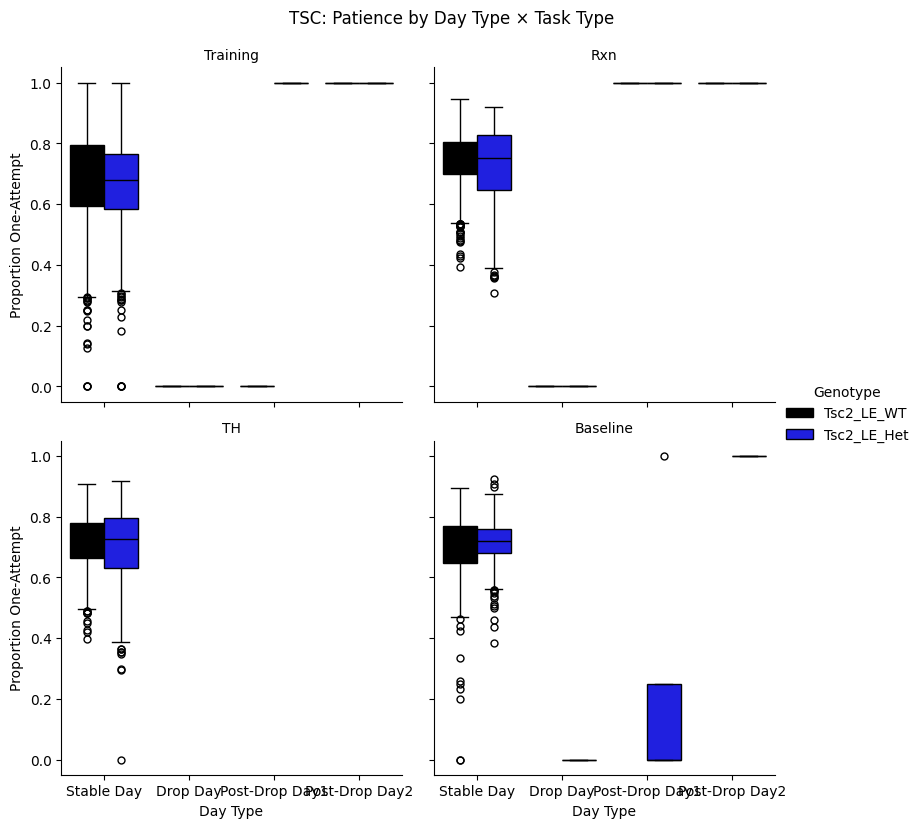

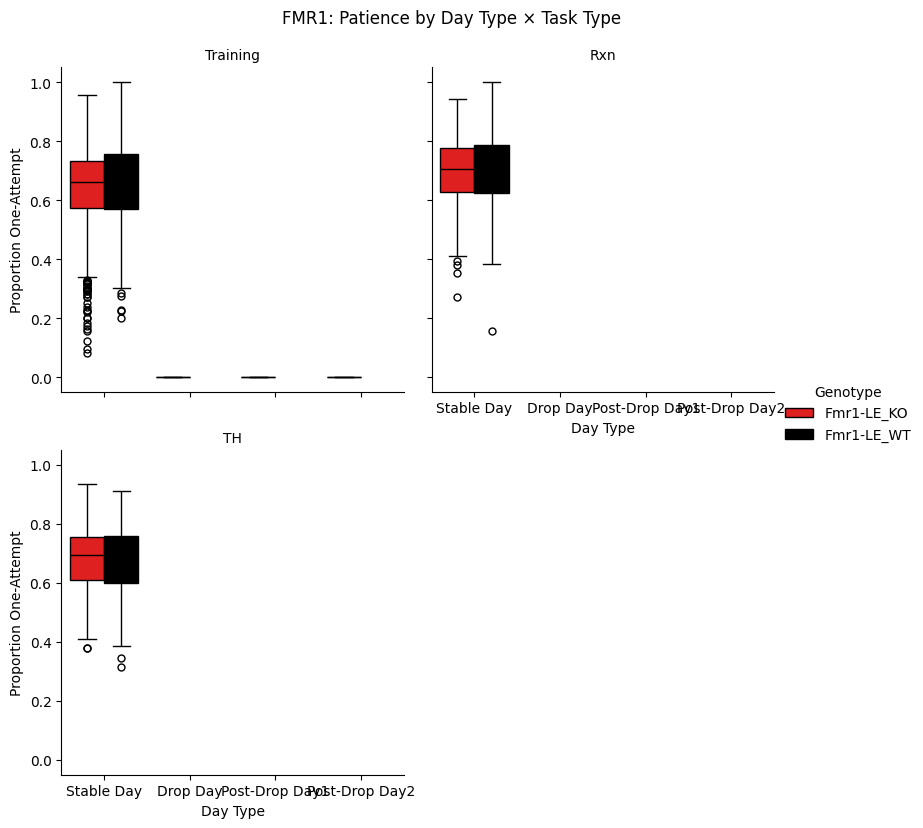

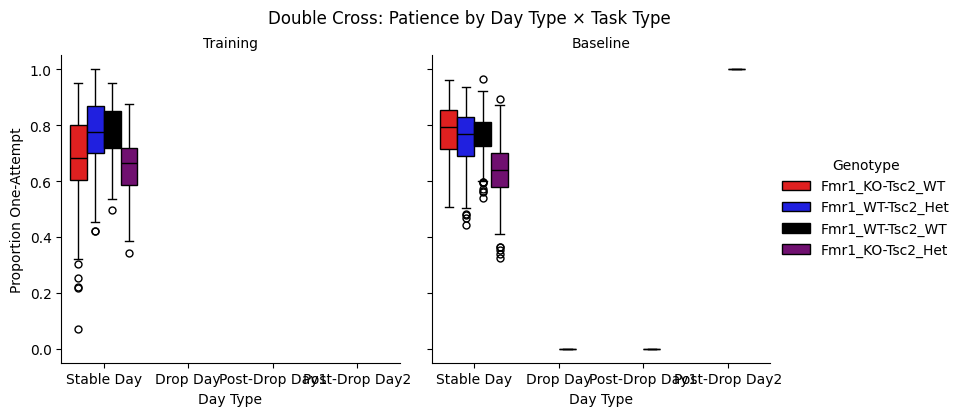

In [103]:
plot_patience_by_task(tsc_patience, "TSC")
plot_patience_by_task(fmr1_patience, "FMR1")
plot_patience_by_task(double_patience, "Double Cross")

In [104]:
def plot_weight_drops(df, label):
    palette = get_active_palette(df)

    plt.figure(figsize=(12,6))

    # Plot each rat
    for rat, group in df.groupby('rat_ID'):
        plt.plot(group['date'], group['weight'],
                 color=palette[group['Genotype'].iloc[0]],
                 alpha=0.4)

        # highlight weight drops
        drop_points = group[group['sig_drop_7']]
        plt.scatter(drop_points['date'], drop_points['weight'],
                    color='red', s=40, zorder=5, label=None)

    plt.title(f"{label}: Weight Trajectories With >7% Drops Highlighted")
    plt.xlabel("Date")
    plt.ylabel("Weight (g)")
    plt.tight_layout()
    plt.show()

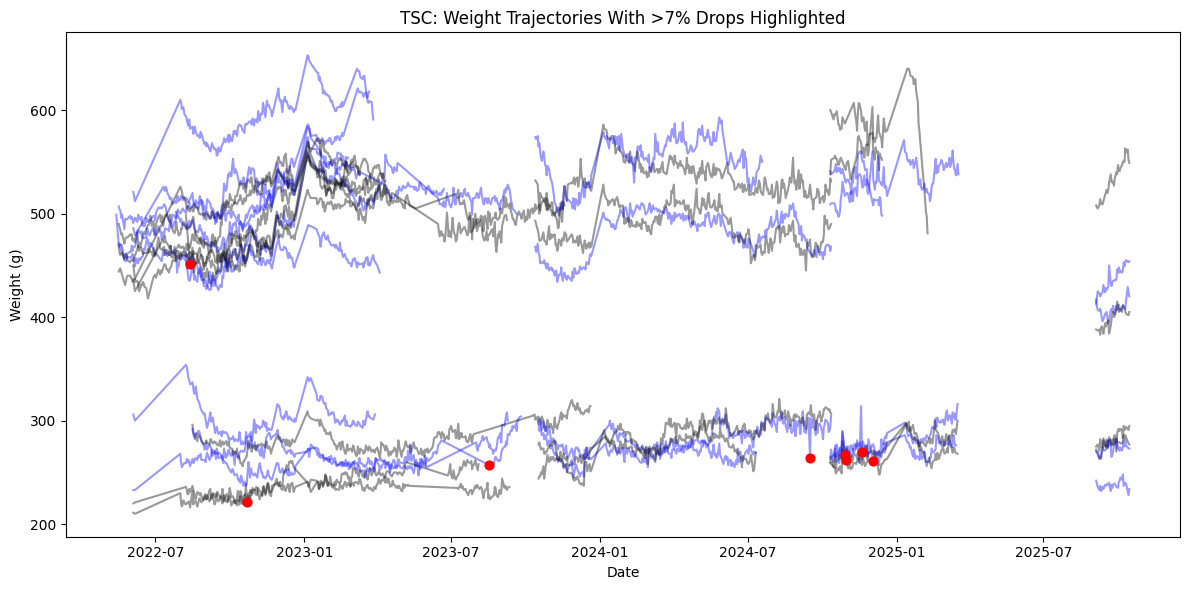

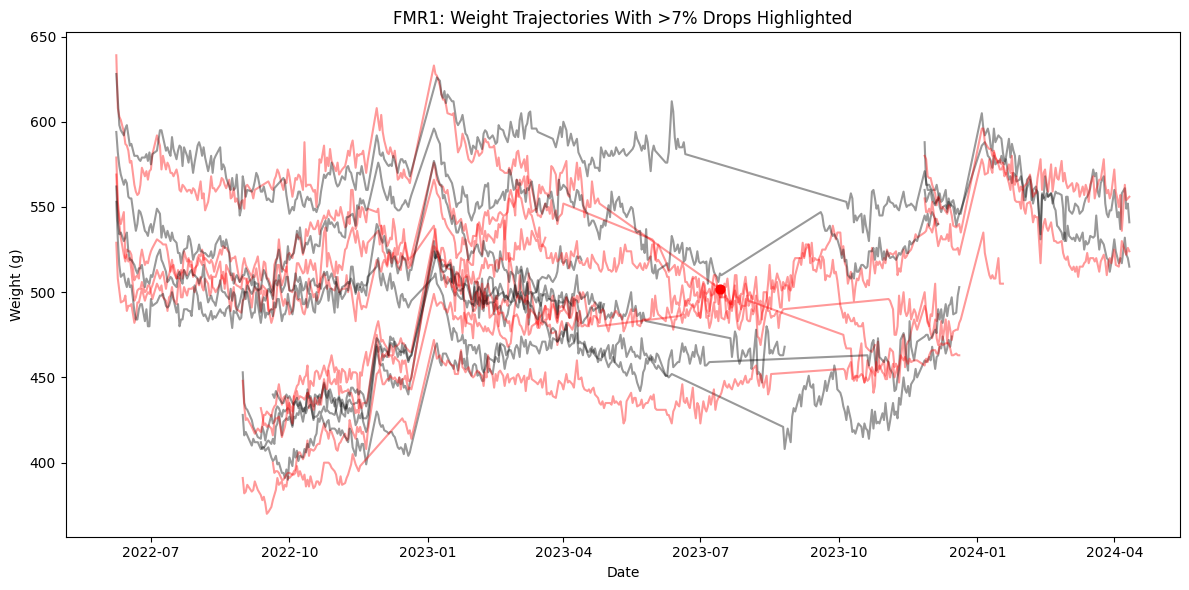

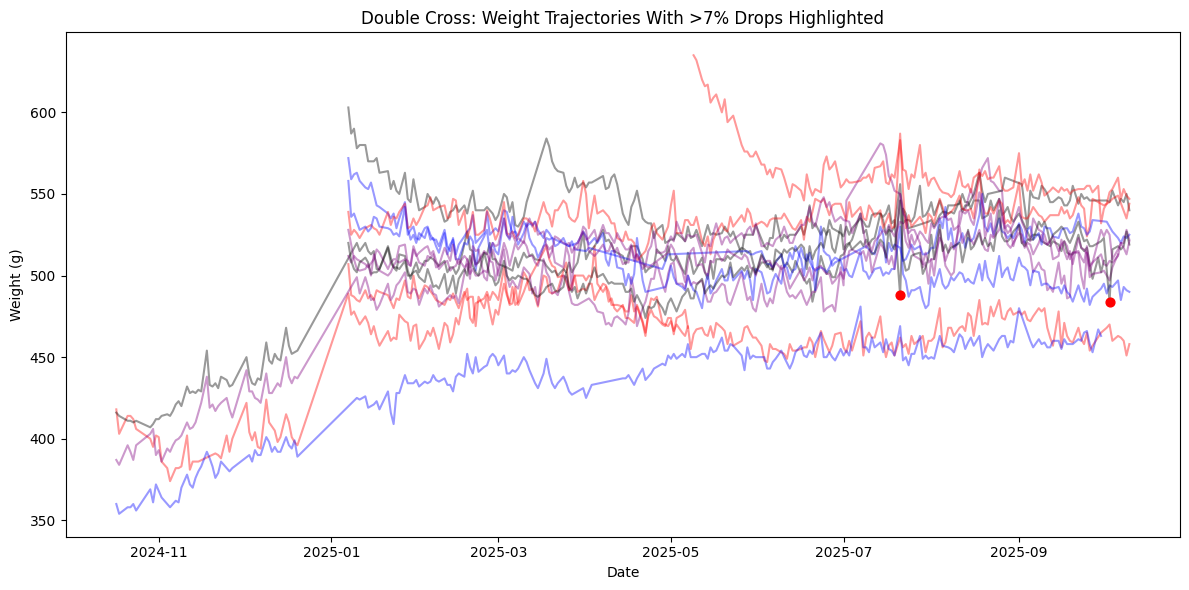

In [105]:
plot_weight_drops(tsc_df, "TSC")
plot_weight_drops(fmr1_df, "FMR1")
plot_weight_drops(double_df, "Double Cross")


## ---- Above are updated code ----

Please ignore the section below for now

**Hypothesis test: Does drop status affect behavior?**

In [46]:
anova_model = ols('mean_attempts ~ C(drop_status)', data=rat_behavior_summary).fit()
anova_table = sm.stats.anova_lm(anova_model, typ=2)
print(anova_table)

                    sum_sq    df         F    PR(>F)
C(drop_status)   36.730694   2.0  5.309228  0.006697
Residual        297.485795  86.0       NaN       NaN


To examine whether significant short-term weight loss influenced behavioral patience, trials were categorized as “Stable,” “Drop,” or “Post-Drop” days based on whether a rat experienced more than a 7% decrease in body weight compared to the previous day. A one-way ANOVA compared the mean number of attempts across these conditions. The analysis revealed a significant main effect of drop status, p < .05 (p = 0.006697), indicating that rats showed higher mean attempts (lower patience) following a significant weight drop. Visualization of mean attempts across drop conditions supports this result, suggesting that physiological stress or energy loss may transiently reduce behavioral persistence in the Tsc2 cohort.

### 4+ days of consistent loss in weight

1. Gradual small losses each day (like -2%, -3%, -1%, -2%)

2. One sharp drop followed by sustained low weight.

In [47]:
# Sort by rat and date
merged_df = merged_df.sort_values(['rat_ID', 'date']).copy()

# Compute day-to-day weight difference
merged_df['weight_diff'] = merged_df.groupby('rat_ID')['weight'].diff()
merged_df['weight_loss'] = merged_df['weight_diff'] < 0

# Compute consecutive weight loss streaks per rat safely
def compute_streaks(x):
    streak = 0
    streaks = []
    for loss in x:
        if loss:
            streak += 1
        else:
            streak = 0
        streaks.append(streak)
    return pd.Series(streaks, index=x.index)

merged_df['loss_streak'] = merged_df.groupby('rat_ID')['weight_loss'].transform(compute_streaks)

# Flag 4+ day consistent loss
merged_df['cons_loss_4plus'] = merged_df['loss_streak'] >= 4

print(merged_df[['rat_ID', 'date', 'weight', 'weight_diff', 'loss_streak', 'cons_loss_4plus']].head(15))

         rat_ID       date  weight  weight_diff  loss_streak  cons_loss_4plus
1136578     137 2022-05-17   490.0          NaN            0            False
1136579     137 2022-05-17   490.0          0.0            0            False
1136580     137 2022-05-17   490.0          0.0            0            False
1136581     137 2022-05-17   490.0          0.0            0            False
1136582     137 2022-05-17   490.0          0.0            0            False
1136583     137 2022-05-17   490.0          0.0            0            False
1136584     137 2022-05-17   490.0          0.0            0            False
1136585     137 2022-05-17   490.0          0.0            0            False
1136586     137 2022-05-17   490.0          0.0            0            False
1136587     137 2022-05-17   490.0          0.0            0            False
1136588     137 2022-05-17   490.0          0.0            0            False
1136589     137 2022-05-17   490.0          0.0            0    

In [48]:
streak_summary = merged_df.groupby('rat_ID')['cons_loss_4plus'].sum().reset_index(name='n_streaks')
print(streak_summary.sort_values('n_streaks', ascending=False).head())

   rat_ID  n_streaks
0     137          0
1     138          0
2     139          0
3     140          0
4     141          0


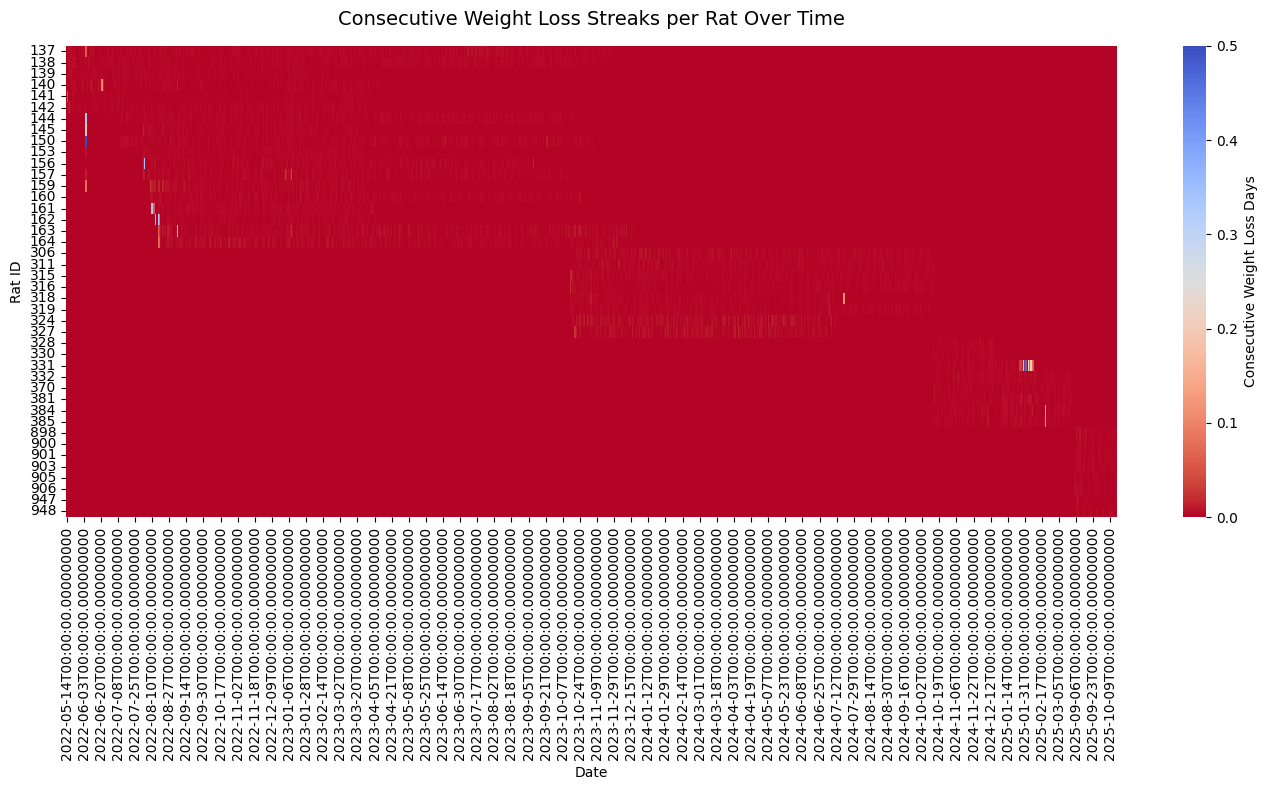

In [49]:
# Sort by date and rat
merged_df = merged_df.sort_values(['rat_ID', 'date'])

# Pivot table: rows = rats, columns = dates, values = loss_streak
pivot_df = merged_df.pivot_table(
    index='rat_ID',
    columns='date',
    values='loss_streak',
    aggfunc='mean'
).fillna(0)

plt.figure(figsize=(14, 8))
sns.heatmap(
    pivot_df,
    cmap='coolwarm_r',
    cbar_kws={'label': 'Consecutive Weight Loss Days'},
    linewidths=0
)
plt.title('Consecutive Weight Loss Streaks per Rat Over Time', fontsize=14, pad=15)
plt.xlabel('Date')
plt.ylabel('Rat ID')
plt.tight_layout()
plt.show()

As we can see here there weren't many rats with a 4-day weight drop.

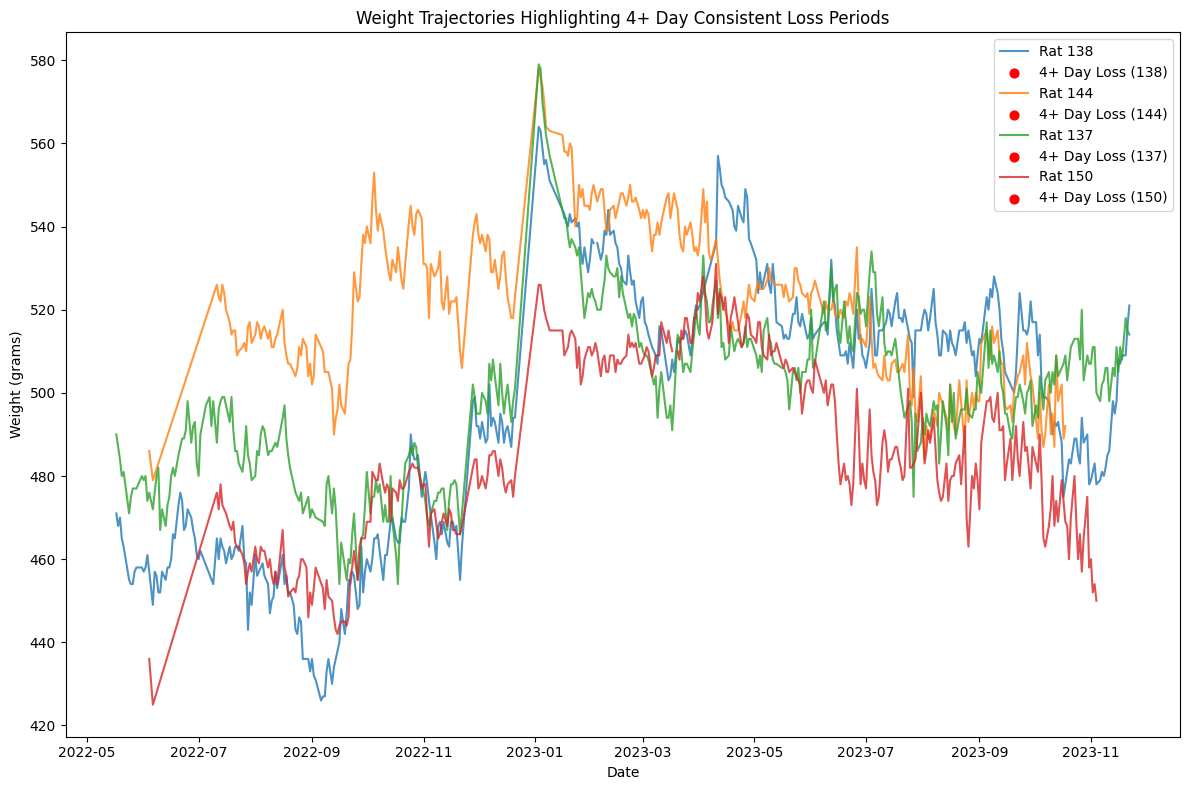

In [50]:
# Choose a few sample rats to visualize
sample_rats = merged_df['rat_ID'].value_counts().index[:4]  # top 4 rats by session count

plt.figure(figsize=(12, 8))
for rat in sample_rats:
    subset = merged_df[merged_df['rat_ID'] == rat]
    plt.plot(subset['date'], subset['weight'], label=f'Rat {rat}', alpha=0.8)
    plt.scatter(subset.loc[subset['cons_loss_4plus'], 'date'],
                subset.loc[subset['cons_loss_4plus'], 'weight'],
                color='red', s=40, label=f'4+ Day Loss ({rat})')

plt.title('Weight Trajectories Highlighting 4+ Day Consistent Loss Periods')
plt.xlabel('Date')
plt.ylabel('Weight (grams)')
plt.legend()
plt.tight_layout()
plt.show()

Since we don't have many rat with a 4-day continous weight drop so this graph (for four sample rats) doesn't have any red dot on it.

These visualizations reveal when each rat entered periods of consistent weight loss and how those periods align with behavioral measures. The heatmap highlights individual differences across rats, while the line plots show temporal patterns and recovery dynamics. Together, these plots illustrate the potential link between sustained weight loss and reduced task patience in the Tsc2 model.

**Test Behavior differences**

In [51]:
#from scipy.stats import ttest_ind

#loss_group = merged_df[merged_df['cons_loss_4plus']]['Attempts_to_complete']
#stable_group = merged_df[~merged_df['cons_loss_4plus']]['Attempts_to_complete']

#t, p = ttest_ind(loss_group, stable_group, equal_var=False)
#print(f"T-test: t={t:.3f}, p={p:.4f}")

NA results (try to fix)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_32840\1677170698.py:14: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


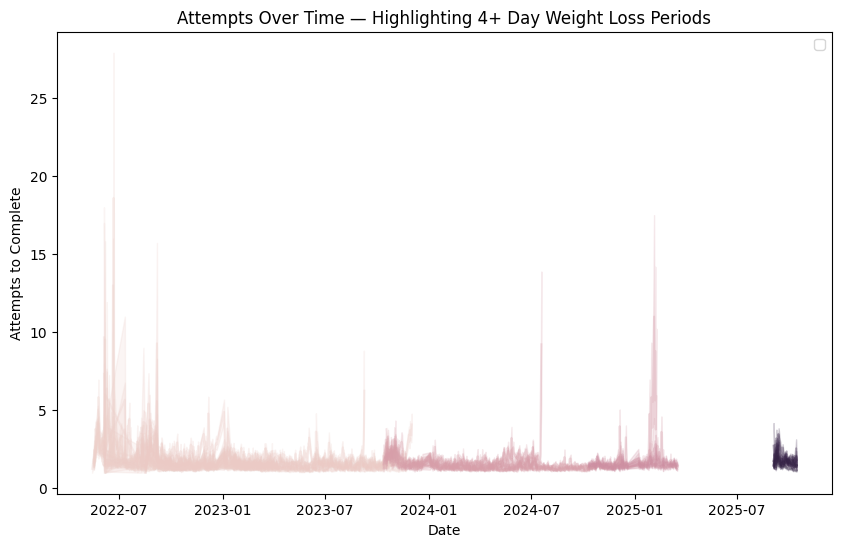

In [52]:
plt.figure(figsize=(10,6))
sns.lineplot(
    data=merged_df,
    x='date', y='Attempts_to_complete', hue='rat_ID',
    alpha=0.3, legend=False
)
sns.scatterplot(
    data=merged_df[merged_df['cons_loss_4plus']],
    x='date', y='Attempts_to_complete', color='red', label='4+ Day Weight Loss'
)
plt.title("Attempts Over Time — Highlighting 4+ Day Weight Loss Periods")
plt.xlabel("Date")
plt.ylabel("Attempts to Complete")
plt.legend()
plt.show()

I'm not sure is 4+ days of consistent loss in weight significant here now since it's a bit hard to find those in the data (maybe I'm still missing something but this is what I got so far)

**Does a rat’s weight change on day t-1 predict its behavioral patience (attempts) on day t?**

In [53]:
merged_df = merged_df.sort_values(['rat_ID', 'date']).copy()

# Compute percent weight change from previous day
merged_df['pct_weight_change'] = merged_df.groupby('rat_ID')['weight'].pct_change() * 100

# Shift weight change forward by one day to align with next day's behavior
merged_df['prev_day_weight_change'] = merged_df.groupby('rat_ID')['pct_weight_change'].shift(1)

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_32840\475338487.py:4: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  merged_df['pct_weight_change'] = merged_df.groupby('rat_ID')['weight'].pct_change() * 100


In [54]:
# Compute per rat/day summary: proportion of one-attempt trials
daily_behavior = (
    merged_df.groupby(['rat_ID', 'date', 'Sex', 'Genotype'])
    .agg({
        'weight': 'mean',
        'prev_day_weight_change': 'mean',
        'Attempts_to_complete': lambda x: (x == 1).mean()  # proportion of one-attempt trials
    })
    .reset_index()
    .rename(columns={'Attempts_to_complete': 'prop_one_attempt'})
)

prop_one_attempt → behavioral patience

prev_day_weight_change → previous day’s physiological change

In [55]:
# Drop rows with any NA values in model variables
model_data = daily_behavior.dropna(subset=['prop_one_attempt', 'prev_day_weight_change', 'Sex', 'Genotype'])

print("Before:", len(daily_behavior))
print("After dropna:", len(model_data))

Before: 8293
After dropna: 8292


In [56]:
model_data = model_data.reset_index(drop=True)

In [57]:
model_data['rat_ID'] = model_data['rat_ID'].astype('category')

In [58]:
import statsmodels.formula.api as smf

model = smf.mixedlm(
    "prop_one_attempt ~ prev_day_weight_change + Sex + Genotype",
    data=model_data,
    groups=model_data["rat_ID"]
).fit()

print(model.summary())

              Mixed Linear Model Regression Results
Model:             MixedLM  Dependent Variable:  prop_one_attempt
No. Observations:  8292     Method:              REML            
No. Groups:        42       Scale:               0.0120          
Min. group size:   34       Log-Likelihood:      6492.6017       
Max. group size:   438      Converged:           Yes             
Mean group size:   197.4                                         
-----------------------------------------------------------------
                       Coef.  Std.Err.   z    P>|z| [0.025 0.975]
-----------------------------------------------------------------
Intercept               0.702    0.016 43.108 0.000  0.670  0.734
Sex[T.Male]            -0.008    0.018 -0.464 0.643 -0.044  0.027
Genotype[T.Tsc2_LE_WT]  0.003    0.018  0.170 0.865 -0.032  0.038
prev_day_weight_change -0.049    0.012 -4.126 0.000 -0.073 -0.026
Group Var               0.003    0.007                           



c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


A linear mixed-effects model was conducted to examine whether the previous day’s weight change predicted the next day’s proportion of one-attempt trials, controlling for sex and genotype, with rat ID included as a random effect to account for repeated measures across sessions.

The model converged successfully (n = 8,292 observations across 42 rats). Results showed that the previous day’s weight change was a significant predictor of next-day performance, β = −0.049, SE = 0.012, z = −4.13, p < .001. The negative coefficient indicates that greater weight loss on the previous day (i.e., more negative percent change) was associated with a lower proportion of one-attempt trials the following day—meaning rats became less patient or consistent in completing trials after experiencing a short-term physiological stressor.

In contrast, sex (β = −0.008, p = .64) and genotype (β = 0.003, p = .87) were not significant predictors, suggesting that the effect of weight change on behavioral patience was not moderated by biological sex or genotype differences.

The random-effect variance estimate (σ² = 0.003) indicates modest variability between individual rats after accounting for the fixed effects, confirming that the overall relationship between weight loss and behavioral performance was consistent across subjects.

A mixed-effects model revealed that changes in body weight significantly predicted subsequent behavioral performance. Specifically, greater weight loss on the previous day was associated with a lower proportion of single-attempt trials (β = −0.049, p < .001), indicating reduced patience and task persistence following short-term physiological stress. This relationship held even after controlling for sex and genotype, suggesting that transient reductions in body weight have a robust, generalizable effect on performance across the Tsc2 rat population.

**Visualizations**

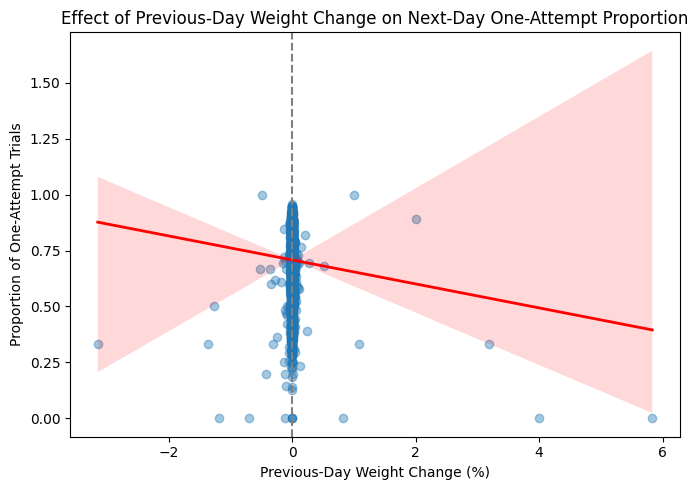

In [59]:
plt.figure(figsize=(7,5))
sns.regplot(
    data=model_data,
    x='prev_day_weight_change',
    y='prop_one_attempt',
    scatter_kws={'alpha':0.4},
    line_kws={'color':'red', 'lw':2}
)
plt.title("Effect of Previous-Day Weight Change on Next-Day One-Attempt Proportion")
plt.xlabel("Previous-Day Weight Change (%)")
plt.ylabel("Proportion of One-Attempt Trials")
plt.axvline(0, color='gray', linestyle='--')
plt.tight_layout()
plt.show()

C:\Users\LENOVO\AppData\Local\Temp\ipykernel_32840\1465494975.py:42: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


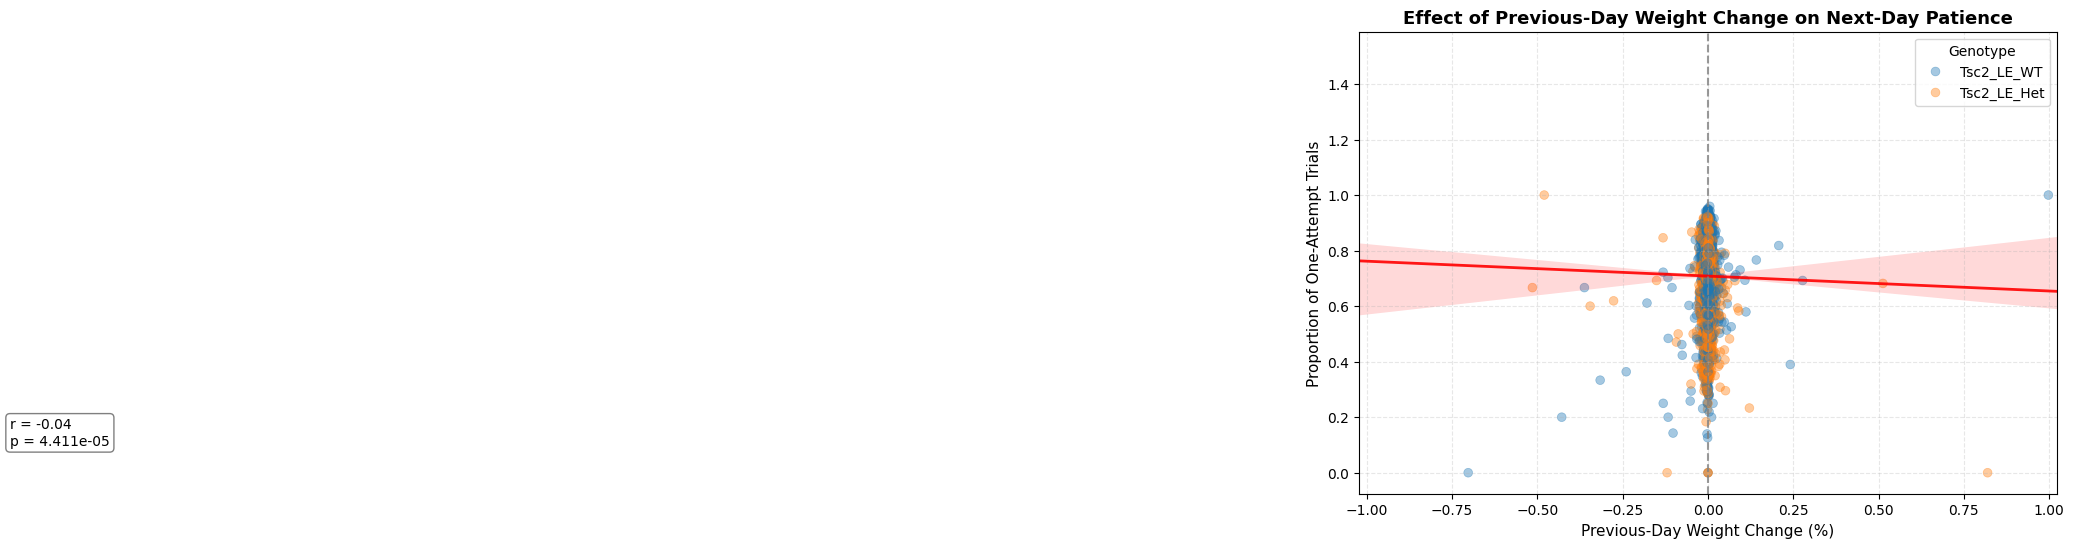

In [ ]:
plt.figure(figsize=(9,6))

sns.scatterplot(
    data=model_data,
    x='prev_day_weight_change',
    y='prop_one_attempt',
    hue='Genotype',            
    alpha=0.4,
    s=40,                      
    edgecolor=None
)

sns.regplot(
    data=model_data,
    x='prev_day_weight_change',
    y='prop_one_attempt',
    scatter=False,
    color='red',
    line_kws={'lw':2, 'alpha':0.9}
)

plt.title("Effect of Previous-Day Weight Change on Next-Day Patience", fontsize=13, weight='bold')
plt.xlabel("Previous-Day Weight Change (%)", fontsize=11)
plt.ylabel("Proportion of One-Attempt Trials", fontsize=11)

xmin, xmax = model_data['prev_day_weight_change'].quantile([0.01, 0.99])
plt.xlim(xmin - 1, xmax + 1)

plt.axvline(0, color='gray', linestyle='--', alpha=0.8)

plt.grid(True, linestyle='--', alpha=0.3)

from scipy.stats import pearsonr
r, p = pearsonr(model_data['prev_day_weight_change'], model_data['prop_one_attempt'])
plt.text(xmax - 5, 0.1, f"r = {r:.2f}\np = {p:.3e}", fontsize=10,
         bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3'))

plt.tight_layout()
plt.show()

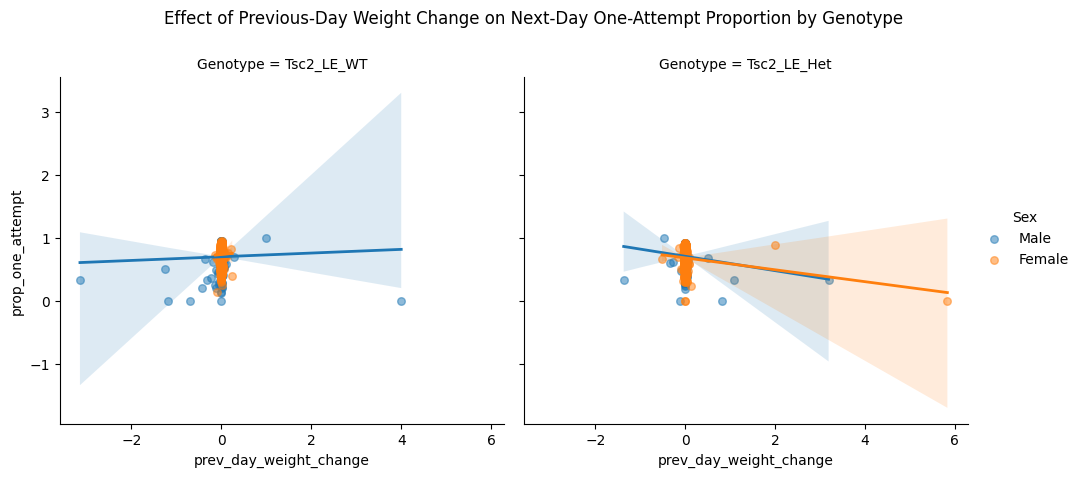

In [ ]:

from scipy.stats import pearsonr

# Calculate correlation by genotype for annotation
corrs = (
    model_data.groupby('Genotype')[['prev_day_weight_change', 'prop_one_attempt']]
    .apply(lambda df: pearsonr(df['prev_day_weight_change'], df['prop_one_attempt'])[0])
    .reset_index(name='corr')
)

# Create facet plot
g = sns.lmplot(
    data=model_data,
    x='prev_day_weight_change',
    y='prop_one_attempt',
    hue='Sex',
    col='Genotype',
    height=4.8,
    aspect=1.15,
    scatter_kws={'alpha':0.4, 's':35},
    line_kws={'lw':2, 'alpha':0.9},
    palette='Set2',
    ci=95
)

# Improve layout and labels
g.set_titles(col_template="{col_name}")
g.set_axis_labels("Previous-Day Weight Change (%)", "Proportion of One-Attempt Trials")
g.fig.subplots_adjust(top=0.88)
g.fig.suptitle("Effect of Previous-Day Weight Change on Next-Day Patience by Genotype", fontsize=14, weight='bold')

# Add gridlines to all panels
for ax in g.axes.flat:
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.axvline(0, color='gray', linestyle='--', alpha=0.7)

# Expand x-axis range (centered around 0)
xmin, xmax = model_data['prev_day_weight_change'].quantile([0.01, 0.99])
for ax in g.axes.flat:
    ax.set_xlim(xmin - 1, xmax + 1)

# Optional: add correlation annotations
for ax, (_, row) in zip(g.axes.flat, corrs.iterrows()):
    ax.text(
        0.05, 0.9,
        f"r = {row['corr']:.2f}",
        transform=ax.transAxes,
        fontsize=10,
        bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3')
    )

plt.show()


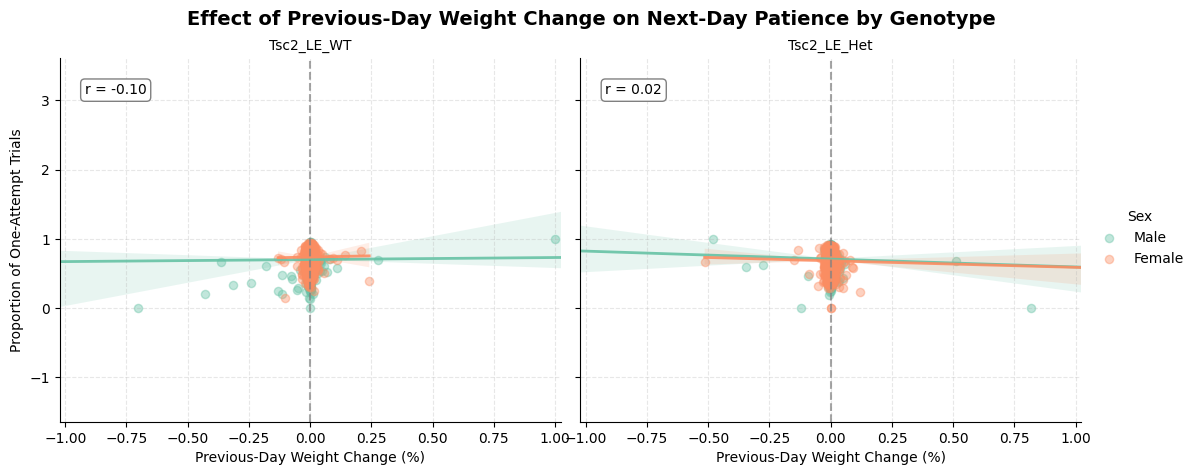

In [78]:
corrs = (
    model_data.groupby('Genotype')[['prev_day_weight_change', 'prop_one_attempt']]
    .apply(lambda df: pearsonr(df['prev_day_weight_change'], df['prop_one_attempt'])[0])
    .reset_index(name='corr')
)

g = sns.lmplot(
    data=model_data,
    x='prev_day_weight_change',
    y='prop_one_attempt',
    hue='Sex',
    col='Genotype',
    height=4.8,
    aspect=1.15,
    scatter_kws={'alpha':0.4, 's':35},
    line_kws={'lw':2, 'alpha':0.9},
    palette='Set2',
    ci=95
)

g.set_titles(col_template="{col_name}")
g.set_axis_labels("Previous-Day Weight Change (%)", "Proportion of One-Attempt Trials")
g.fig.subplots_adjust(top=0.88)
g.fig.suptitle("Effect of Previous-Day Weight Change on Next-Day Patience by Genotype", fontsize=14, weight='bold')

for ax in g.axes.flat:
    ax.grid(True, linestyle='--', alpha=0.3)
    ax.axvline(0, color='gray', linestyle='--', alpha=0.7)

xmin, xmax = model_data['prev_day_weight_change'].quantile([0.01, 0.99])
for ax in g.axes.flat:
    ax.set_xlim(xmin - 1, xmax + 1)

for ax, (_, row) in zip(g.axes.flat, corrs.iterrows()):
    ax.text(
        0.05, 0.9,
        f"r = {row['corr']:.2f}",
        transform=ax.transAxes,
        fontsize=10,
        bbox=dict(facecolor='white', edgecolor='gray', boxstyle='round,pad=0.3')
    )

plt.show()

Each panel shows the slope of the relationship within one genotype.
The x-axis: % weight change from the previous day
The y-axis: proportion of one-attempt trials (patience)
The line represents the fitted regression trend, and the shaded region is the 95% confidence interval.
A steeper negative slope in one genotype (Tsc2_LE_Het) indicates that rats in that group are more behaviorally sensitive to weight loss (stronger carryover stress effect).

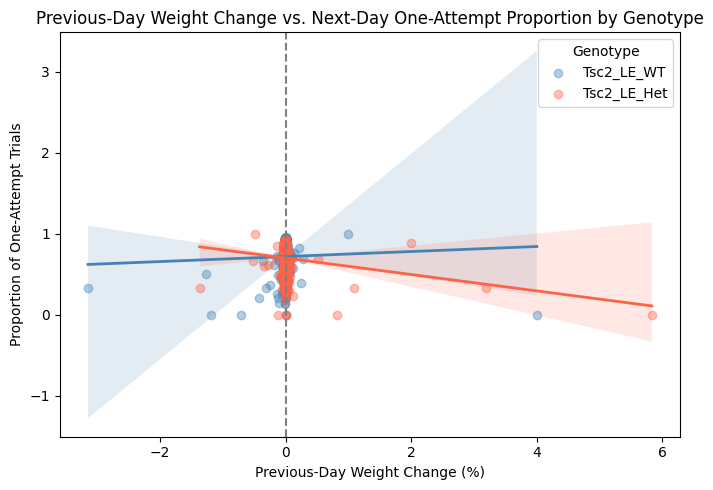

In [62]:
plt.figure(figsize=(7,5))
sns.regplot(
    data=model_data[model_data['Genotype'] == 'Tsc2_LE_WT'],
    x='prev_day_weight_change',
    y='prop_one_attempt',
    label='Tsc2_LE_WT',
    scatter_kws={'alpha':0.4, 'color':'steelblue'},
    line_kws={'color':'steelblue', 'lw':2}
)
sns.regplot(
    data=model_data[model_data['Genotype'] == 'Tsc2_LE_Het'],
    x='prev_day_weight_change',
    y='prop_one_attempt',
    label='Tsc2_LE_Het',
    scatter_kws={'alpha':0.4, 'color':'tomato'},
    line_kws={'color':'tomato', 'lw':2}
)
plt.title("Previous-Day Weight Change vs. Next-Day One-Attempt Proportion by Genotype")
plt.xlabel("Previous-Day Weight Change (%)")
plt.ylabel("Proportion of One-Attempt Trials")
plt.axvline(0, color='gray', linestyle='--')
plt.legend(title='Genotype')
plt.tight_layout()
plt.show()

# False Alarm Rate & Patient

In [63]:
# Compute session-level patience metrics from trial data
session_behavior = (
    merged_df.groupby(['UUID', 'rat_ID', 'date', 'Sex', 'Genotype'])
    .agg({
        'Attempts_to_complete': [
            lambda x: (x == 1).mean(),   # proportion of one-attempt trials
            'mean'                       # mean attempts
        ],
        'Delay (s)': 'mean'
    })
    .reset_index()
)

session_behavior.columns = [
    'UUID', 'rat_ID', 'date', 'Sex', 'Genotype',
    'prop_one_attempt', 'mean_attempts', 'mean_delay'
]

# Pull in FA_percent and hit_percent (they’re constant per UUID)
session_info = merged_df.drop_duplicates('UUID')[
    ['UUID', 'FA_percent', 'hit_percent']
]

# Merge behavior + FA info
session_df = pd.merge(session_behavior, session_info, on='UUID', how='left')

session_df.head()

,UUID,rat_ID,date,Sex,Genotype,prop_one_attempt,mean_attempts,mean_delay,FA_percent,hit_percent
0,20220514151757_103.9730027318_0.130505200966487,141,2022-05-14,Male,Tsc2_LE_Het,0.750000,1.250000,0.191165,NaN,1.000000
1,20220517151752_67.6900070160627_0.066518474156...,141,2022-05-17,Male,Tsc2_LE_Het,0.619048,1.952381,0.241130,NaN,0.904762
2,20220517151754_80.0100065767765_0.073360024604...,137,2022-05-17,Male,Tsc2_LE_WT,0.761905,1.452381,0.244433,NaN,0.976190
3,20220517151759_22.4860075861216_0.174686616683777,142,2022-05-17,Male,Tsc2_LE_WT,0.718750,1.562500,0.247036,NaN,0.875000
4,20220517151801_167.185001447797_0.328728352456273,138,2022-05-17,Male,Tsc2_LE_Het,0.593750,1.843750,0.269960,NaN,0.781250


In [64]:
session_df.isna().sum()

UUID                  0
rat_ID                0
date                  0
Sex                   0
Genotype              0
prop_one_attempt      0
mean_attempts         0
mean_delay            0
FA_percent          377
hit_percent           0
dtype: int64

In [65]:
session_df["FA_percent"].value_counts()

FA_percent
1.000000    66
0.125000    44
0.200000    43
0.083333    42
0.111111    41
            ..
0.172131     1
0.310924     1
0.700000     1
0.604478     1
0.496552     1
Name: count, Length: 3148, dtype: int64

In [66]:
check_df = merged_df[['UUID', 'trial_count', 'complete_block_count', 'FA_percent', 'hit_percent']]

# Check if FA_percent is NaN while hit_percent exists
print("Rows where FA_percent is NaN but hit_percent is valid:", 
      ((check_df['FA_percent'].isna()) & (check_df['hit_percent'].notna())).sum())

# Check average trial_count for FA missing vs not missing
print(check_df.groupby(check_df['FA_percent'].isna())['trial_count'].describe())

Rows where FA_percent is NaN but hit_percent is valid: 74784
                count        mean        std  min    25%    50%    75%    max
FA_percent                                                                   
False       2877398.0  396.092233  98.001235  2.0  332.0  407.0  469.0  710.0
True          74784.0  252.714538  81.119940  1.0  199.0  248.0  311.0  433.0


Remaining sessions after dropping NA in FA_percent: 7951


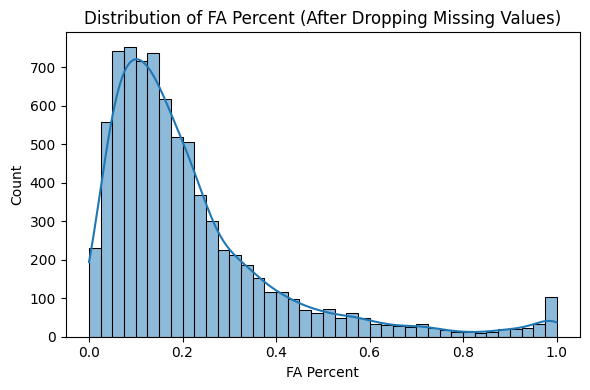

In [67]:
# Drop sessions where FA_percent is missing (likely incomplete sessions)
session_df = session_df.dropna(subset=['FA_percent']).reset_index(drop=True)

print(f"Remaining sessions after dropping NA in FA_percent: {len(session_df)}")

# Optional: quick check
plt.figure(figsize=(6,4))
sns.histplot(session_df['FA_percent'], bins=40, kde=True)
plt.title("Distribution of FA Percent (After Dropping Missing Values)")
plt.xlabel("FA Percent")
plt.tight_layout()
plt.show()

**Box-Cox transform (For Normalization)**

In [68]:
from scipy.stats import boxcox

fa_positive = np.where(session_df['FA_percent'] <= 0, 1e-4, session_df['FA_percent'])
session_df['FA_boxcox'], lam = boxcox(fa_positive)
print("Box-Cox λ:", lam)

Box-Cox λ: 0.22685122072421066


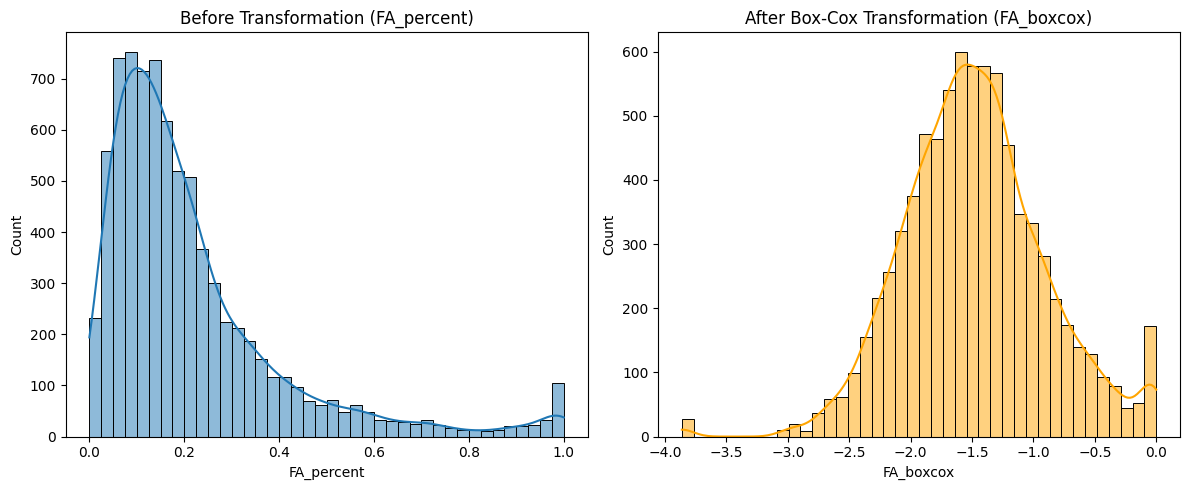

In [69]:
plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
sns.histplot(session_df['FA_percent'], bins=40, kde=True)
plt.title("Before Transformation (FA_percent)")

plt.subplot(1,2,2)
sns.histplot(session_df['FA_boxcox'], bins=40, kde=True, color='orange')
plt.title("After Box-Cox Transformation (FA_boxcox)")
plt.tight_layout()
plt.show()

**FA_Percent Correlation with Patientce (Prop One Attempt)**

In [70]:
from scipy.stats import pearsonr

r, p = pearsonr(session_df['FA_boxcox'], session_df['prop_one_attempt'])
print(f"Correlation (FA_boxcox vs prop_one_attempt): r={r:.3f}, p={p:.4f}")

Correlation (FA_boxcox vs prop_one_attempt): r=-0.186, p=0.0000


We can see a weak negative correlation (higher FA (more impulsive) → less patience)

**Mixed Model (controlling for sex & genotype)**

In [71]:
model_fa_boxcox = smf.mixedlm(
    "prop_one_attempt ~ FA_boxcox + Sex + Genotype",
    data=session_df,
    groups=session_df["rat_ID"]
).fit()

print(model_fa_boxcox.summary())

              Mixed Linear Model Regression Results
Model:              MixedLM  Dependent Variable:  prop_one_attempt
No. Observations:   7951     Method:              REML            
No. Groups:         42       Scale:               0.0101          
Min. group size:    27       Log-Likelihood:      6896.8851       
Max. group size:    436      Converged:           Yes             
Mean group size:    189.3                                         
------------------------------------------------------------------
                       Coef.  Std.Err.    z    P>|z| [0.025 0.975]
------------------------------------------------------------------
Intercept               0.656    0.017  39.440 0.000  0.623  0.688
Sex[T.Male]            -0.011    0.018  -0.618 0.537 -0.046  0.024
Genotype[T.Tsc2_LE_WT]  0.006    0.018   0.351 0.725 -0.029  0.041
FA_boxcox              -0.038    0.002 -15.895 0.000 -0.042 -0.033
Group Var               0.003    0.008                            



c:\Users\LENOVO\AppData\Local\Programs\Python\Python313\Lib\site-packages\statsmodels\regression\mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [72]:
model_fa_boxcox.pvalues['FA_boxcox']

np.float64(6.825855400373177e-57)

The relationship between Box-Cox normalized FA rate and behavioral patience was highly significant (p = 6.825841715481971e-57), indicating a robust, consistent association across sessions. Rats that exhibited higher false alarm rates (maybe greater impulsivity) showed significantly lower proportions of one-attempt trials, suggesting that reduced patience and increased impulsivity are strongly linked behavioral patterns rather than random session-to-session fluctuations.

**Visualization**

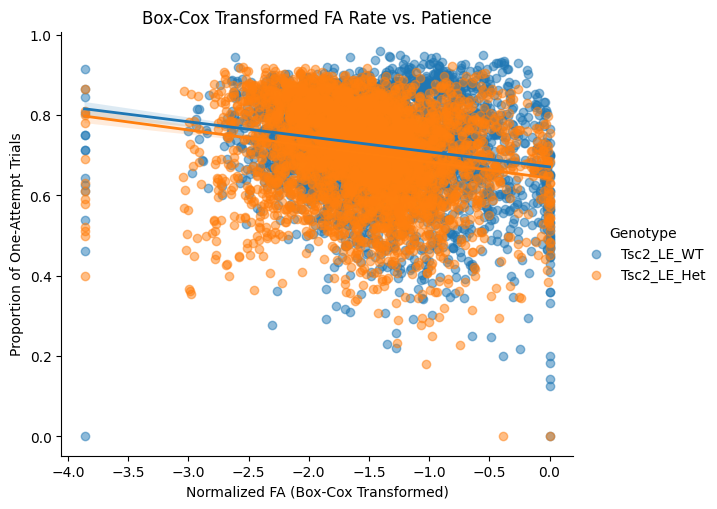

In [73]:
sns.lmplot(
    data=session_df,
    x='FA_boxcox', y='prop_one_attempt',
    hue='Genotype',
    height=5, aspect=1.2,
    scatter_kws={'alpha':0.5}, line_kws={'lw':2}
)
plt.title("Box-Cox Transformed FA Rate vs. Patience")
plt.xlabel("Normalized FA (Box-Cox Transformed)")
plt.ylabel("Proportion of One-Attempt Trials")
plt.show()

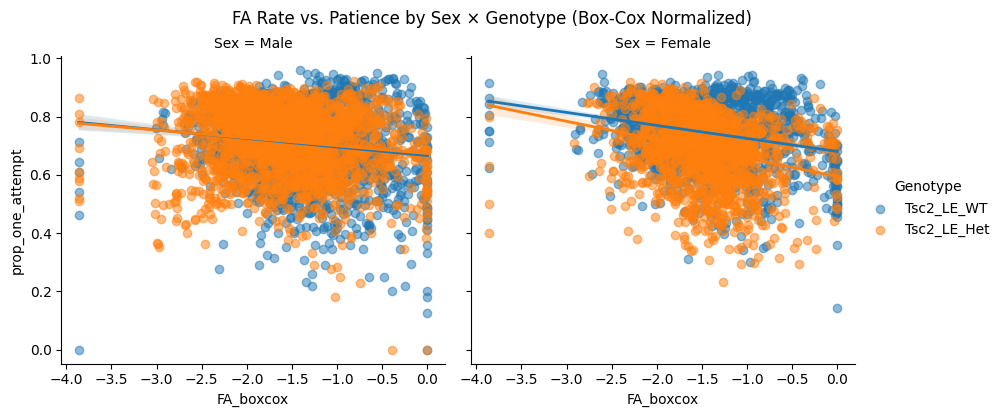

In [74]:
sns.lmplot(
    data=session_df,
    x='FA_boxcox', y='prop_one_attempt',
    hue='Genotype', col='Sex',
    height=4, aspect=1.1,
    scatter_kws={'alpha':0.5}, line_kws={'lw':2}
)
plt.suptitle("FA Rate vs. Patience by Sex × Genotype (Box-Cox Normalized)", y=1.03)
plt.show()